# DSA COMPFEST 18 — Soil Organic Content Prediction

**Kompetisi**: Seleksi Data Science Academy COMPFEST 18  
**Target**: `property_organic_content` — kandungan organik tanah Brasil  
**Metrik**: RMSE (Root Mean Squared Error)  
**Bobot**: 90% Research Questions + 10% Kaggle Score  

---
**Strategi Pipeline v3:**
- OOF Target Encoding untuk 5 fitur kategorik kunci
- Feature interactions: source×biome, particle×spectral
- LightGBM + CatBoost (Optuna-tuned) + HistGradientBoosting
- Ridge Stacking meta-learner
- KFold vs GroupKFold comparison untuk diagnosis gap OOF↔LB

## 01. Import Library & Konfigurasi

In [1]:
# =============================================================
# 01. IMPORT LIBRARY
# =============================================================
import numpy as np
import pandas as pd
import warnings
import os
import time
import json
import pickle

warnings.filterwarnings('ignore')

# ML Core
import lightgbm as lgb
import catboost as cb
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, GroupKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Hyperparameter Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# SHAP
import shap

# Stats
from scipy import stats
from scipy.stats import kruskal, chi2_contingency, spearmanr

# =============================================================
# KONFIGURASI GLOBAL
# =============================================================
SEED     = 42
N_FOLDS  = 5
TARGET   = 'property_organic_content'
DATA_DIR = '/kaggle/input/competitions/seleksi-data-science-academy-compfest-18'
OUT_DIR  = '/kaggle/working/'

np.random.seed(SEED)
os.makedirs(OUT_DIR, exist_ok=True)

# Matplotlib style
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#1a1a2e',
    'axes.edgecolor'   : '#444466',
    'axes.labelcolor'  : '#e0e0ff',
    'xtick.color'      : '#b0b0d0',
    'ytick.color'      : '#b0b0d0',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#2a2a4a',
    'grid.linewidth'   : 0.5,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'figure.titlesize' : 15,
})

# Color palette
PALETTE_BIOME = {
    'Cerrado'         : '#f4a261',
    'Mata Atlântica'  : '#2a9d8f',
    'Amazonia'        : '#264653',
    'Caatinga'        : '#e76f51',
    'Unknown'         : '#6c757d',
}

def rmse(y_true, y_pred):
    """Root Mean Squared Error — metrik utama kompetisi."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

print(f'Libraries loaded | NumPy {np.__version__} | Pandas {pd.__version__} | LightGBM {lgb.__version__}')
print(f'SEED={SEED} | N_FOLDS={N_FOLDS} | TARGET={TARGET}')

Libraries loaded | NumPy 2.4.6 | Pandas 2.3.3 | LightGBM 4.6.0
SEED=42 | N_FOLDS=5 | TARGET=property_organic_content


## 02. Load Data

In [2]:
# =============================================================
# 02. LOAD DATA
# =============================================================
print('=' * 60)
print('LOADING DATA')
print('=' * 60)

train_raw = pd.read_csv(f'{DATA_DIR}/train.csv')
test_raw  = pd.read_csv(f'{DATA_DIR}/test.csv')
sub       = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

# Simpan IDs
train_ids = train_raw['sample_id'].copy()
test_ids  = test_raw['sample_id'].copy()

print(f'Train : {train_raw.shape}')
print(f'Test  : {test_raw.shape}')
print(f'Sub   : {sub.shape}')
print(f'\nTarget Statistics:')
print(f'  Mean     : {train_raw[TARGET].mean():.4f}')
print(f'  Std      : {train_raw[TARGET].std():.4f}')
print(f'  Min      : {train_raw[TARGET].min():.4f}')
print(f'  Max      : {train_raw[TARGET].max():.4f}')
print(f'  Skewness : {train_raw[TARGET].skew():.4f}')
print(f'  Kurtosis : {train_raw[TARGET].kurtosis():.4f}')

# Missing value overview
print(f'\nMissing Value Summary (Train):')
miss = train_raw.isnull().sum()
miss_pct = (miss / len(train_raw) * 100).round(1)
miss_df = pd.DataFrame({'count': miss, 'pct': miss_pct}).query('count > 0').sort_values('pct', ascending=False)
print(miss_df.to_string())

# Source ID target mean analysis — krusial!
print(f'\nSource ID Target Mean (sample):')
src_stats = train_raw.groupby('source_id')[TARGET].agg(['mean','std','count']).sort_values('mean', ascending=False)
print(src_stats.head(10).to_string())

LOADING DATA
Train : (11210, 52)
Test  : (2670, 51)
Sub   : (2670, 2)

Target Statistics:
  Mean     : 34.1425
  Std      : 23.1986
  Min      : 2.1574
  Max      : 195.2315
  Skewness : 2.0278
  Kurtosis : 6.0820

Missing Value Summary (Train):
                          count   pct
cation_Na                 10808  96.4
spectral_band_B_PC_7       9516  84.9
spectral_band_B_PC_5       9516  84.9
spectral_band_B_PC_6       9516  84.9
spectral_band_B_PC_4       9516  84.9
spectral_band_B_PC_3       9516  84.9
spectral_band_B_PC_2       9516  84.9
spectral_band_B_PC_1       9516  84.9
spectral_band_B_PC_12      9516  84.9
spectral_band_B_PC_9       9516  84.9
spectral_band_B_PC_10      9516  84.9
spectral_band_B_PC_11      9516  84.9
spectral_band_B_PC_14      9516  84.9
spectral_band_B_PC_13      9516  84.9
spectral_band_B_PC_15      9516  84.9
spectral_band_B_PC_8       9516  84.9
latitude                   8820  78.7
longitude                  8820  78.7
property_acidity_index     8405 

## 03. Exploratory Data Analysis (EDA)

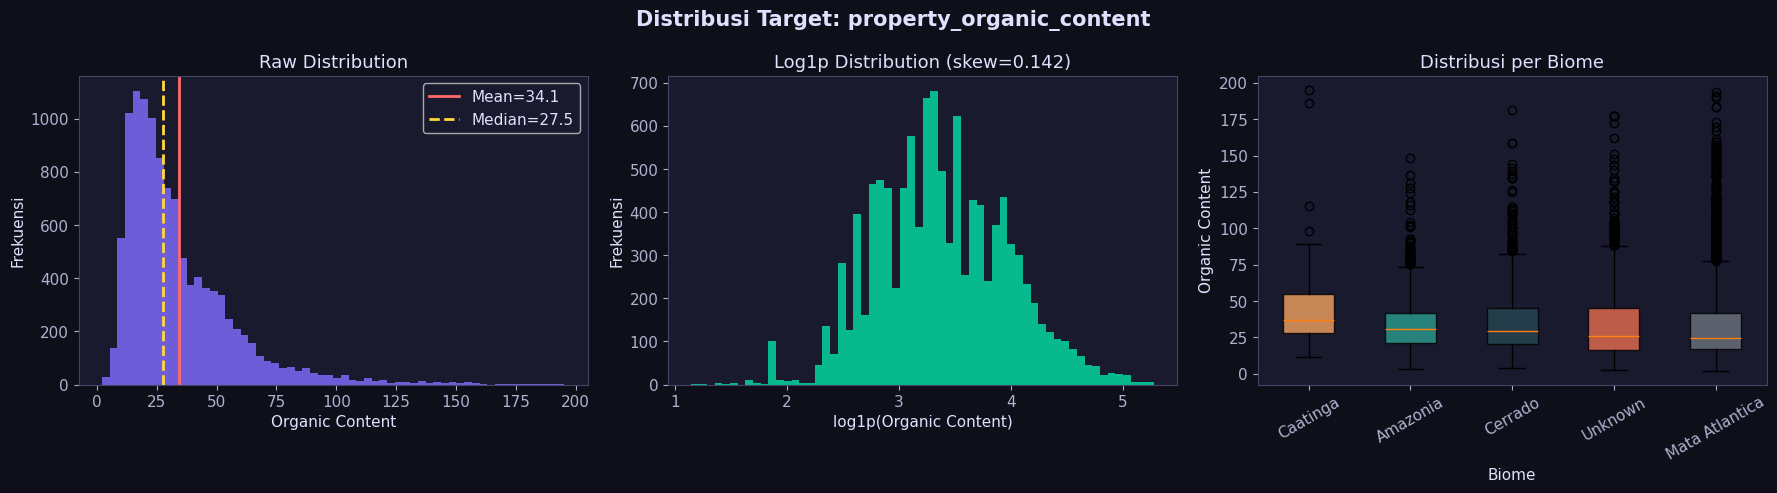

✅ Figure saved: eda_target_distribution.png


In [3]:
# =============================================================
# 03.1 DISTRIBUSI TARGET
# =============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Target: property_organic_content', fontsize=15, fontweight='bold')

# Raw distribution
ax = axes[0]
ax.hist(train_raw[TARGET], bins=60, color='#7c6af7', edgecolor='none', alpha=0.85)
ax.set_title('Raw Distribution')
ax.set_xlabel('Organic Content')
ax.set_ylabel('Frekuensi')
ax.axvline(train_raw[TARGET].mean(), color='#ff6b6b', lw=2, label=f'Mean={train_raw[TARGET].mean():.1f}')
ax.axvline(train_raw[TARGET].median(), color='#ffd93d', lw=2, ls='--', label=f'Median={train_raw[TARGET].median():.1f}')
ax.legend()

# Log1p distribution
log_target = np.log1p(train_raw[TARGET])
ax = axes[1]
ax.hist(log_target, bins=60, color='#06d6a0', edgecolor='none', alpha=0.85)
ax.set_title(f'Log1p Distribution (skew={log_target.skew():.3f})')
ax.set_xlabel('log1p(Organic Content)')
ax.set_ylabel('Frekuensi')

# Per Biome boxplot
ax = axes[2]
biome_order = train_raw.groupby('biome')[TARGET].median().sort_values(ascending=False).index.tolist()
biome_data  = [train_raw[train_raw['biome'] == b][TARGET].dropna().values for b in biome_order]
bplot = ax.boxplot(biome_data, labels=biome_order, patch_artist=True, vert=True, notch=False)
colors_bp = ['#f4a261','#2a9d8f','#264653','#e76f51','#6c757d']
for patch, color in zip(bplot['boxes'], colors_bp[:len(biome_order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title('Distribusi per Biome')
ax.set_xlabel('Biome')
ax.set_ylabel('Organic Content')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('✅ Figure saved: eda_target_distribution.png')

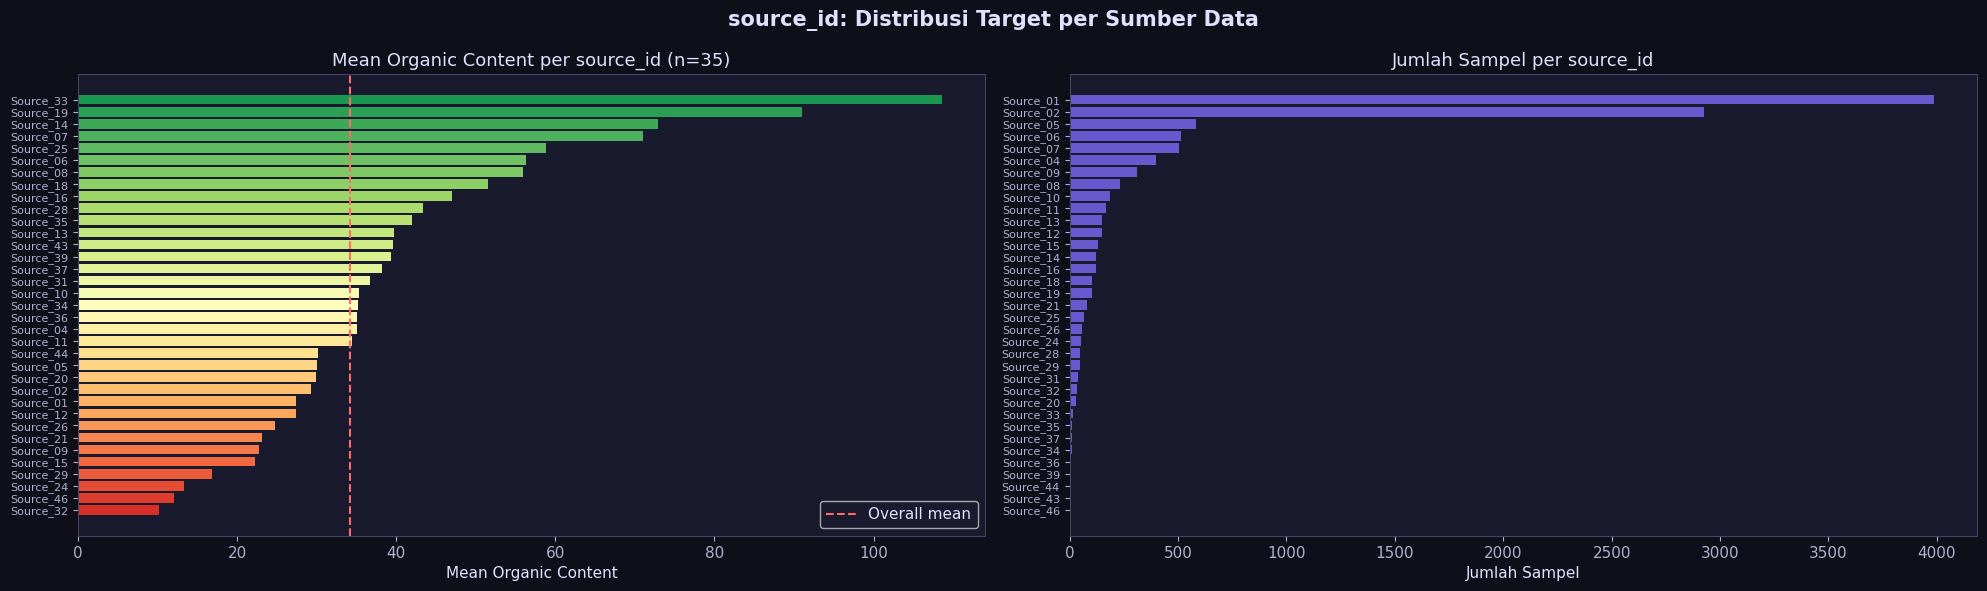

Range mean per source: 10.23 – 108.60
Rasio max/min: 10.6x
Semua source_id test ada di train: True


In [4]:
# =============================================================
# 03.2 SOURCE_ID — FITUR PALING KRUSIAL
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('source_id: Distribusi Target per Sumber Data', fontsize=15, fontweight='bold')

src_mean = train_raw.groupby('source_id')[TARGET].mean().sort_values(ascending=True)

ax = axes[0]
colors_bar = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(src_mean)))
bars = ax.barh(range(len(src_mean)), src_mean.values, color=colors_bar, edgecolor='none')
ax.set_yticks(range(len(src_mean)))
ax.set_yticklabels(src_mean.index, fontsize=8)
ax.set_xlabel('Mean Organic Content')
ax.set_title('Mean Organic Content per source_id (n=35)')
ax.axvline(train_raw[TARGET].mean(), color='#ff6b6b', lw=1.5, ls='--', label='Overall mean')
ax.legend()

# Source ID count
ax = axes[1]
src_count = train_raw.groupby('source_id')[TARGET].count().sort_values(ascending=True)
ax.barh(range(len(src_count)), src_count.values, color='#7c6af7', edgecolor='none', alpha=0.8)
ax.set_yticks(range(len(src_count)))
ax.set_yticklabels(src_count.index, fontsize=8)
ax.set_xlabel('Jumlah Sampel')
ax.set_title('Jumlah Sampel per source_id')

plt.tight_layout()
plt.savefig('eda_source_id.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

# Statistik kunci
print(f'Range mean per source: {src_mean.min():.2f} – {src_mean.max():.2f}')
print(f'Rasio max/min: {src_mean.max()/src_mean.min():.1f}x')
print(f'Semua source_id test ada di train: {set(test_raw["source_id"]).issubset(set(train_raw["source_id"]))}')

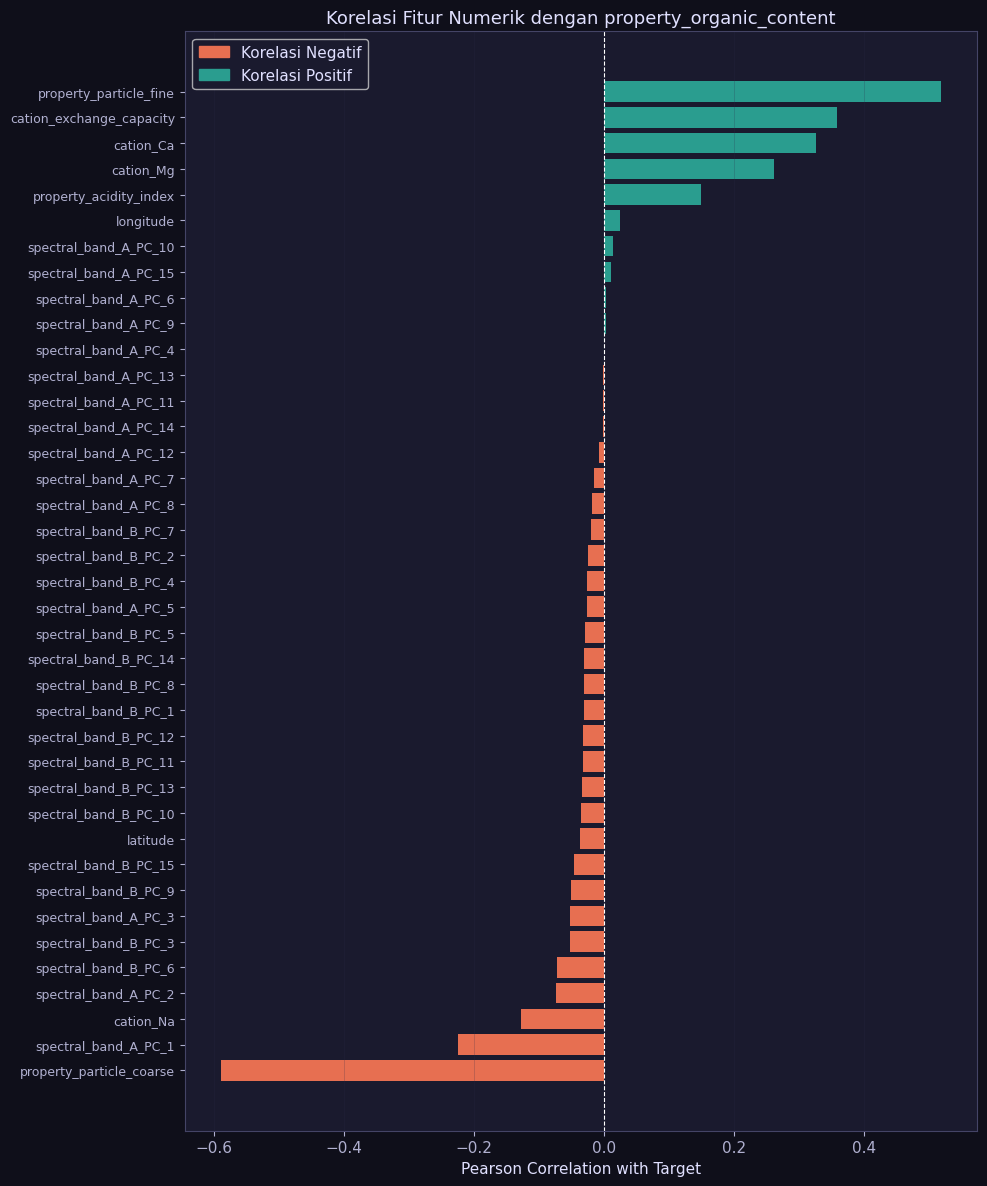

Top 10 fitur berkorelasi dengan target:
property_particle_coarse   -0.589811
spectral_band_A_PC_1       -0.224427
cation_Na                  -0.127774
spectral_band_A_PC_2       -0.074124
spectral_band_B_PC_6       -0.072962
property_acidity_index      0.148721
cation_Mg                   0.261784
cation_Ca                   0.326319
cation_exchange_capacity    0.358489
property_particle_fine      0.518146


In [5]:
# =============================================================
# 03.3 KORELASI FITUR NUMERIK DENGAN TARGET
# =============================================================
num_cols = train_raw.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET and 'sample_id' not in c]

corr_with_target = train_raw[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
colors_corr = ['#e76f51' if x < 0 else '#2a9d8f' for x in corr_with_target.values]
ax.barh(range(len(corr_with_target)), corr_with_target.values, color=colors_corr, edgecolor='none')
ax.set_yticks(range(len(corr_with_target)))
ax.set_yticklabels(corr_with_target.index, fontsize=9)
ax.set_xlabel('Pearson Correlation with Target')
ax.set_title('Korelasi Fitur Numerik dengan property_organic_content')
ax.axvline(0, color='white', lw=0.8, ls='--')
ax.grid(axis='x', alpha=0.3)

red_patch = mpatches.Patch(color='#e76f51', label='Korelasi Negatif')
grn_patch = mpatches.Patch(color='#2a9d8f', label='Korelasi Positif')
ax.legend(handles=[red_patch, grn_patch])

plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print('Top 10 fitur berkorelasi dengan target:')
print(pd.concat([corr_with_target.head(5), corr_with_target.tail(5)]).to_string())

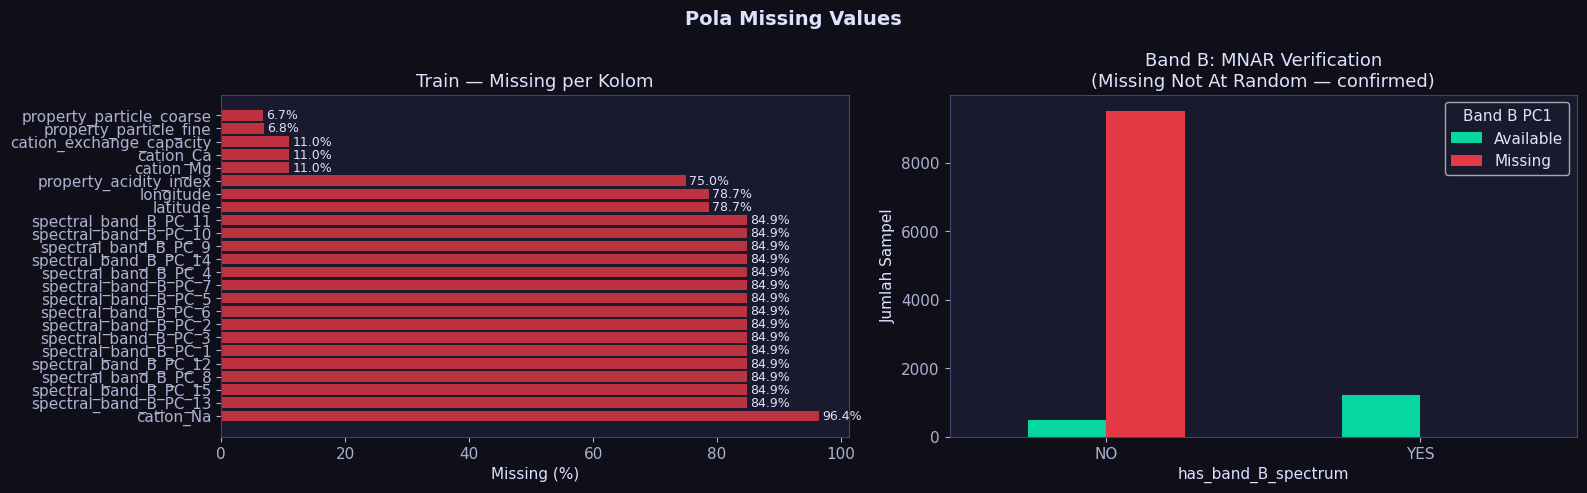

In [6]:
# =============================================================
# 03.4 MISSING VALUE PATTERN
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Pola Missing Values', fontsize=14, fontweight='bold')

# Train missing
miss_train = (train_raw.isnull().mean() * 100).sort_values(ascending=False)
miss_train = miss_train[miss_train > 0]

ax = axes[0]
ax.barh(miss_train.index, miss_train.values, color='#e63946', edgecolor='none', alpha=0.8)
ax.set_xlabel('Missing (%)')
ax.set_title('Train — Missing per Kolom')
for i, v in enumerate(miss_train.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# MNAR analysis: band_B_missing vs has_band_B_spectrum
ax = axes[1]
cross = pd.crosstab(
    train_raw['has_band_B_spectrum'],
    train_raw['spectral_band_B_PC_1'].isna().map({True:'Missing', False:'Available'})
)
cross.plot(kind='bar', ax=ax, color=['#06d6a0', '#e63946'], edgecolor='none', width=0.5)
ax.set_title('Band B: MNAR Verification\n(Missing Not At Random — confirmed)')
ax.set_xlabel('has_band_B_spectrum')
ax.set_ylabel('Jumlah Sampel')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Band B PC1')

plt.tight_layout()
plt.savefig('eda_missing_pattern.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

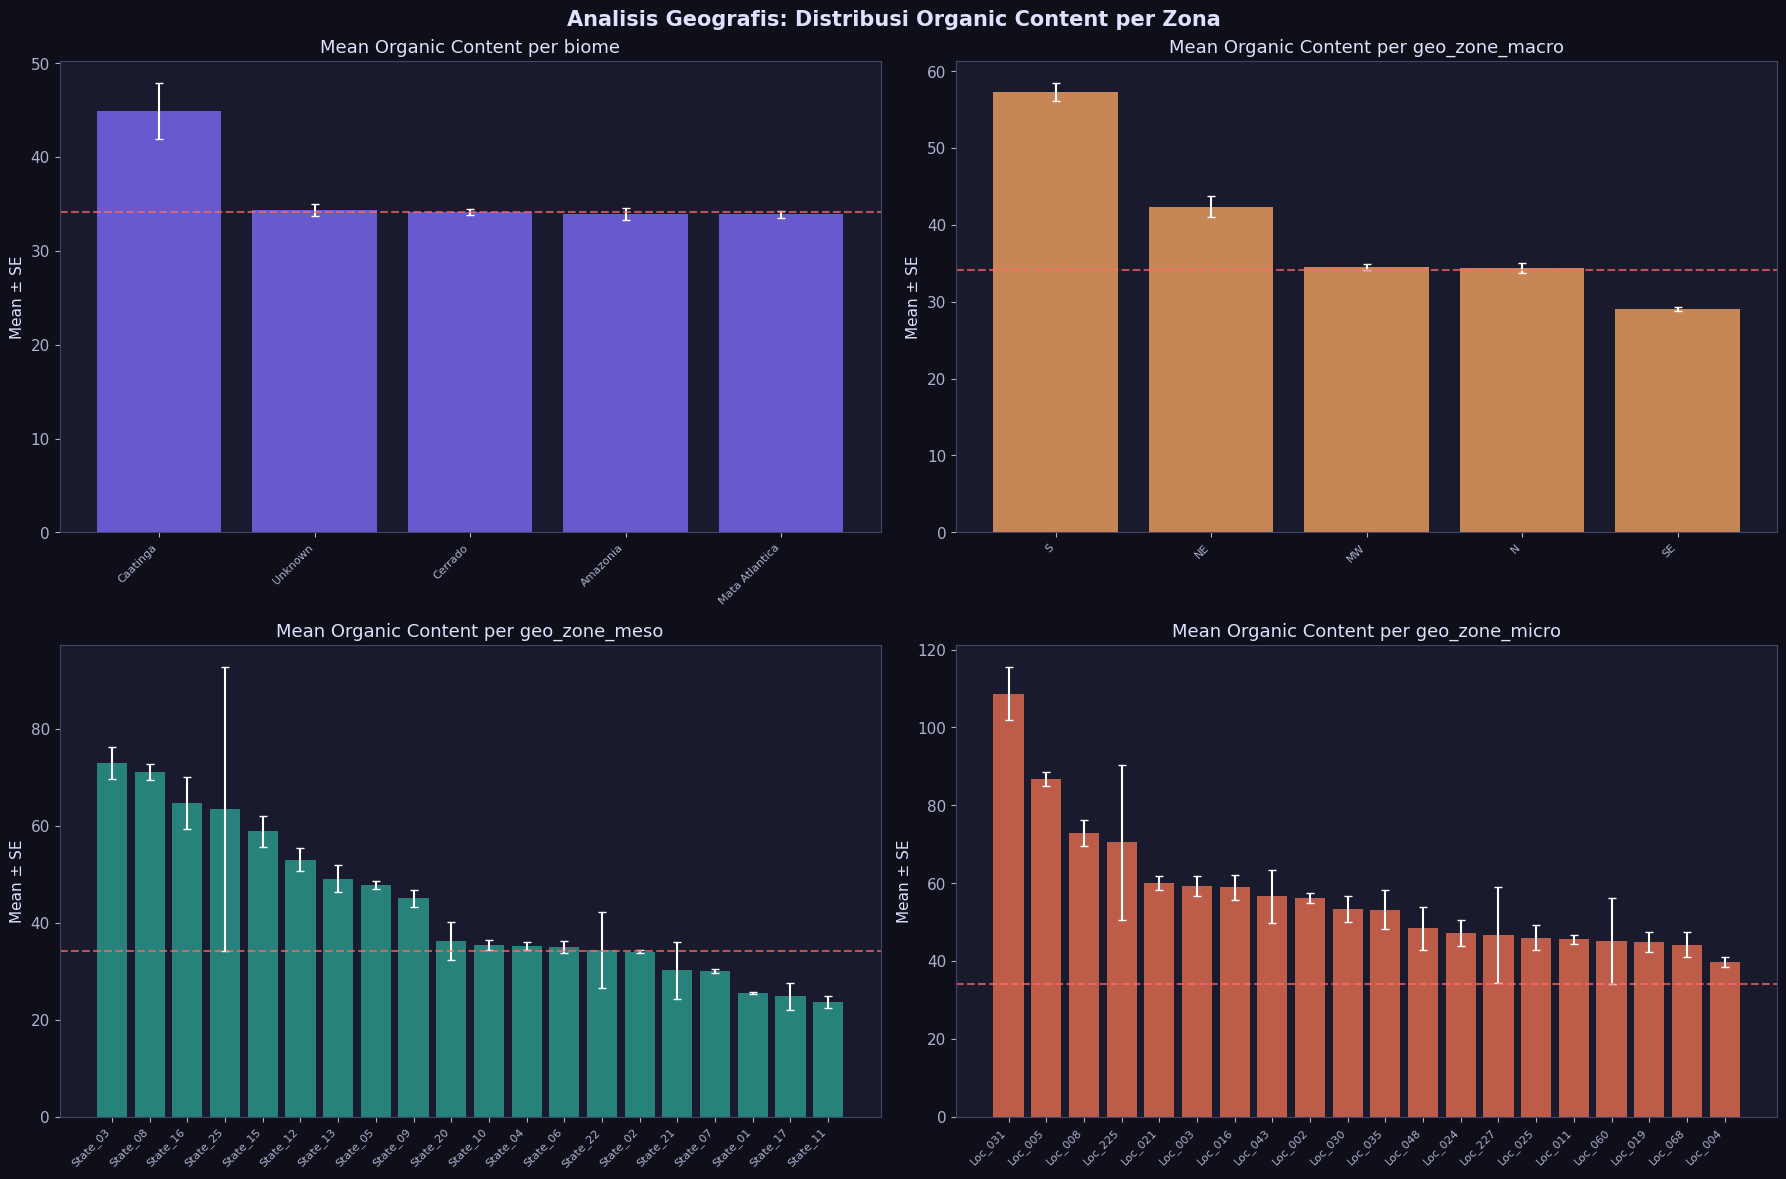

✅ Geographic distribution saved


In [7]:
# =============================================================
# 03.5 DISTRIBUSI GEOGRAFIS (GEO ZONE & BIOME)
# =============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Analisis Geografis: Distribusi Organic Content per Zona', fontsize=15, fontweight='bold')

cat_geo = ['biome', 'geo_zone_macro', 'geo_zone_meso', 'geo_zone_micro']
colors_geo = ['#7c6af7', '#f4a261', '#2a9d8f', '#e76f51']

for ax, col, color in zip(axes.flatten(), cat_geo, colors_geo):
    group_stats = train_raw.groupby(col)[TARGET].agg(['mean', 'std', 'count'])
    group_stats = group_stats.sort_values('mean', ascending=False).head(20)  # top 20 jika terlalu banyak
    
    x_pos = range(len(group_stats))
    bars = ax.bar(x_pos, group_stats['mean'], color=color, alpha=0.8, edgecolor='none')
    ax.errorbar(x_pos, group_stats['mean'], 
                yerr=group_stats['std'] / np.sqrt(group_stats['count']),
                fmt='none', color='white', capsize=3, linewidth=1.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(group_stats.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'Mean Organic Content per {col}')
    ax.set_ylabel('Mean ± SE')
    ax.axhline(train_raw[TARGET].mean(), color='#ff6b6b', lw=1.5, ls='--', alpha=0.7)

plt.tight_layout()
plt.savefig('eda_geographic.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('✅ Geographic distribution saved')

## 04. Preprocessing & Feature Engineering

In [8]:
# =============================================================
# 04.1 FEATURE ENGINEERING (leak-free, tanpa target)
# =============================================================
def feature_engineering(df):
    """
    Seluruh transformasi fitur deterministik — tidak menggunakan
    informasi target sama sekali. Aman untuk train dan test.
    """
    df = df.copy()

    # --- Drop zero-variance & identifier ---
    drop_cols = ['sample_id', 'has_band_A_spectrum', 'sampling_depth_cm']
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    # --- 4.1 Missing Indicators (MNAR signals) ---
    df['band_B_missing']    = df['spectral_band_B_PC_1'].isna().astype(np.int8)
    df['latlon_missing']    = df['latitude'].isna().astype(np.int8)
    df['acidity_missing']   = df['property_acidity_index'].isna().astype(np.int8)
    df['cation_na_missing'] = df['cation_Na'].isna().astype(np.int8)
    df['particle_missing']  = df['property_particle_coarse'].isna().astype(np.int8)
    df['cation_missing']    = df['cation_Ca'].isna().astype(np.int8)

    # --- 4.2 Particle Texture Features ---
    df['particle_ratio'] = df['property_particle_coarse'] / (df['property_particle_fine'] + 1e-6)
    df['particle_sum']   = df['property_particle_coarse'] + df['property_particle_fine']
    df['particle_diff']  = df['property_particle_coarse'] - df['property_particle_fine']
    df['particle_fine_sq'] = df['property_particle_fine'] ** 2   # non-linear
    df['particle_coarse_sq'] = df['property_particle_coarse'] ** 2

    # --- 4.3 Soil Chemistry Features ---
    df['ca_saturation'] = df['cation_Ca']  / (df['cation_exchange_capacity'] + 1e-6)
    df['mg_saturation'] = df['cation_Mg']  / (df['cation_exchange_capacity'] + 1e-6)
    df['cation_sum']    = df['cation_Ca'].fillna(0) + df['cation_Mg'].fillna(0)
    df['base_saturation'] = (df['cation_Ca'].fillna(0) + df['cation_Mg'].fillna(0)) / \
                             (df['cation_exchange_capacity'] + 1e-6)

    # Log-transform kation (right-skewed)
    for col in ['cation_Ca', 'cation_Mg', 'cation_Na', 'cation_exchange_capacity', 'cation_sum']:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

    # --- 4.4 Spectral Band A (selalu tersedia) ---
    band_a = [f'spectral_band_A_PC_{i}' for i in range(1, 16)]
    df['band_A_magnitude']     = np.sqrt((df[band_a] ** 2).sum(axis=1))
    df['band_A_mean']          = df[band_a].mean(axis=1)
    df['band_A_std']           = df[band_a].std(axis=1)
    df['band_A_PC1_PC2_ratio'] = df['spectral_band_A_PC_1'] / (df['spectral_band_A_PC_2'].abs() + 1e-6)
    df['band_A_energy_low']    = np.sqrt((df[band_a[:5]] ** 2).sum(axis=1))   # PC 1-5
    df['band_A_energy_high']   = np.sqrt((df[band_a[10:]] ** 2).sum(axis=1))  # PC 11-15
    df['band_A_PC1_sq']        = df['spectral_band_A_PC_1'] ** 2
    df['band_A_PC2_sq']        = df['spectral_band_A_PC_2'] ** 2

    # --- 4.5 Spectral Band B (85% missing, NaN-aware) ---
    band_b = [f'spectral_band_B_PC_{i}' for i in range(1, 16)]
    df['band_B_magnitude'] = np.sqrt((df[band_b] ** 2).sum(axis=1))
    df['band_B_mean']      = df[band_b].mean(axis=1)
    df['band_AB_ratio']    = df['band_A_magnitude'] / (df['band_B_magnitude'] + 1e-6)

    # --- 4.6 Feature Interactions: Particle × Spectral ---
    df['fine_x_bandA_PC1'] = df['property_particle_fine'] * df['spectral_band_A_PC_1']
    df['fine_x_bandA_PC2'] = df['property_particle_fine'] * df['spectral_band_A_PC_2']
    df['coarse_x_bandA_PC1'] = df['property_particle_coarse'] * df['spectral_band_A_PC_1']
    df['ratio_x_bandA_PC1'] = df['particle_ratio'] * df['spectral_band_A_PC_1']
    df['cec_x_bandA_PC1']  = df['cation_exchange_capacity'] * df['spectral_band_A_PC_1']

    # --- 4.7 Geographic Features ---
    df['abs_latitude']    = df['latitude'].abs()
    df['lat_lon_product'] = df['latitude'] * df['longitude']

    # --- 4.8 Source × Biome interaction (categorical) ---
    df['source_biome'] = (
        df['source_id'].astype(str) + '_' + df['biome'].astype(str)
    )
    df['source_geo_macro'] = (
        df['source_id'].astype(str) + '_' + df['geo_zone_macro'].astype(str)
    )

    # --- 4.9 Categorical Encoding ---
    cat_cols = [
        'source_id', 'has_band_B_spectrum', 'sampling_strategy',
        'geo_zone_macro', 'geo_zone_micro', 'geo_zone_meso',
        'land_cover_type', 'biome', 'parent_rock_type',
        'source_biome', 'source_geo_macro'
    ]
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    return df


# Apply feature engineering
train_fe = feature_engineering(train_raw)
test_fe  = feature_engineering(test_raw)

print(f'Setelah FE → Train: {train_fe.shape} | Test: {test_fe.shape}')
print(f'Fitur baru yang ditambahkan: {train_fe.shape[1] - train_raw.shape[1] + 1} fitur')

Setelah FE → Train: (11210, 89) | Test: (2670, 88)
Fitur baru yang ditambahkan: 38 fitur


In [9]:
# =============================================================
# 04.2 OOF TARGET ENCODING (Leak-Free)
# =============================================================
# Target encoding dilakukan secara OOF:
# - Untuk setiap fold, encoding dihitung HANYA dari fold training
# - Validation fold mendapat encoding dari fold training saja (tidak leakage)
# - Test set mendapat encoding dari SELURUH training set (best practice)

def oof_target_encode(train_df, test_df, cat_col, target_series,
                       n_folds=10, smoothing=10, seed=42):
    """
    Out-of-Fold Target Encoding.

    Rumus smoothing (Bayesian):
        encoded = (n_cat * mean_cat + smoothing * global_mean) / (n_cat + smoothing)

    - smoothing: regularisasi — kategori dengan sedikit sampel ditarik
      lebih kuat ke global mean (mengurangi overfitting pada rare categories)
    - Test set menggunakan full-train statistics (bukan leakage karena
      ini adalah statistik dari populasi, bukan dari target individual)
    """
    global_mean = target_series.mean()
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)

    oof_enc = np.zeros(len(train_df))

    for trn_idx, val_idx in kf.split(train_df):
        trn_cat = train_df[cat_col].iloc[trn_idx]
        trn_tgt = target_series.iloc[trn_idx]
        val_cat = train_df[cat_col].iloc[val_idx]

        # Hitung statistik per kategori dari fold training
        stats_df = pd.DataFrame({'cat': trn_cat, 'tgt': trn_tgt})
        cat_stats = stats_df.groupby('cat', observed=True)['tgt'].agg(['mean', 'count'])
        cat_stats['enc'] = (
            (cat_stats['count'] * cat_stats['mean'] + smoothing * global_mean)
            / (cat_stats['count'] + smoothing)
        )

        # Apply ke validation fold
        val_enc = val_cat.astype(object).map(cat_stats['enc'])
        val_enc = val_enc.fillna(global_mean)  # unseen category → global mean
        oof_enc[val_idx] = val_enc.values

    # Test encoding: full train statistics
    full_stats = pd.DataFrame({'cat': train_df[cat_col], 'tgt': target_series})
    full_cat_stats = full_stats.groupby('cat', observed=True)['tgt'].agg(['mean', 'count'])
    full_cat_stats['enc'] = (
        (full_cat_stats['count'] * full_cat_stats['mean'] + smoothing * global_mean)
        / (full_cat_stats['count'] + smoothing)
    )

    test_enc = test_df[cat_col].astype(object).map(full_cat_stats['enc'])
    test_enc = test_enc.fillna(global_mean)

    return oof_enc, test_enc.values


# Target column for encoding
y_raw_fe = train_fe[TARGET].copy()
y        = np.log1p(y_raw_fe)  # log-transform target

# Kolom yang akan di-encode
encode_cols = [
    'source_id', 'biome', 'geo_zone_macro',
    'geo_zone_meso', 'land_cover_type',
    'source_biome', 'source_geo_macro'
]

train_enc = train_fe.copy()
test_enc  = test_fe.copy()

print('OOF Target Encoding:')
for col in encode_cols:
    if col in train_enc.columns:
        oof_vals, test_vals = oof_target_encode(
            train_enc, test_enc, col, y_raw_fe,
            n_folds=10, smoothing=10, seed=SEED
        )
        new_col = f'{col}_target_enc'
        train_enc[new_col] = oof_vals
        test_enc[new_col]  = test_vals
        print(f'  {col} → {new_col} | range: [{oof_vals.min():.2f}, {oof_vals.max():.2f}]')

print('\n✅ OOF Target Encoding selesai — tidak ada data leakage')
print(f'Total fitur setelah encoding: {train_enc.shape[1]}')

OOF Target Encoding:
  source_id → source_id_target_enc | range: [14.93, 86.74]
  biome → biome_target_enc | range: [33.55, 45.67]
  geo_zone_macro → geo_zone_macro_target_enc | range: [28.86, 57.54]
  geo_zone_meso → geo_zone_meso_target_enc | range: [21.25, 72.31]
  land_cover_type → land_cover_type_target_enc | range: [15.87, 70.56]
  source_biome → source_biome_target_enc | range: [14.93, 86.74]
  source_geo_macro → source_geo_macro_target_enc | range: [14.93, 86.74]

✅ OOF Target Encoding selesai — tidak ada data leakage
Total fitur setelah encoding: 96


In [10]:
# =============================================================
# 04.3 PERSIAPAN DATA UNTUK TRAINING
# =============================================================

# Drop target dari train
train_enc.drop(columns=[TARGET], inplace=True)

# Align kolom test = train
common_cols = [c for c in train_enc.columns if c in test_enc.columns]
test_enc = test_enc[common_cols]

# Simpan source_id untuk GroupKFold (sebelum encoding jadi numerik)
source_id_train = train_raw['source_id'].copy()

# List fitur kategorik
cat_cols_model = [c for c in train_enc.columns if train_enc[c].dtype.name == 'category']
print(f'Categorical features ({len(cat_cols_model)}): {cat_cols_model}')
print(f'Total features: {train_enc.shape[1]}')
print(f'Total rows train: {train_enc.shape[0]}')

# Sanity check: tidak ada target leak
assert TARGET not in train_enc.columns, 'LEAKAGE DETECTED!'
assert TARGET not in test_enc.columns, 'LEAKAGE DETECTED!'
print('\n✅ Data siap — tidak ada target leakage')

Categorical features (11): ['source_id', 'has_band_B_spectrum', 'sampling_strategy', 'geo_zone_macro', 'geo_zone_micro', 'geo_zone_meso', 'land_cover_type', 'biome', 'parent_rock_type', 'source_biome', 'source_geo_macro']
Total features: 95
Total rows train: 11210

✅ Data siap — tidak ada target leakage


## 05. CV Strategy Comparison

In [11]:
# =============================================================
# 05. PERBANDINGAN KFold vs GroupKFold
# =============================================================
# Hipotesis: Gap OOF↔LB 0.83 terjadi karena KFold biasa
# membiarkan model "melihat" sampel dari source yang sama di train+val.
# GroupKFold lebih konservatif dan jujur.

kf  = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
gkf = GroupKFold(n_splits=N_FOLDS)

folds_kfold  = list(kf.split(train_enc, y))
folds_group  = list(gkf.split(train_enc, y, groups=source_id_train))

print('KFold fold sizes:')
for i, (trn, val) in enumerate(folds_kfold):
    print(f'  Fold {i+1}: train={len(trn)} | val={len(val)} | sources_in_val={source_id_train.iloc[val].nunique()}')

print('\nGroupKFold fold sizes:')
for i, (trn, val) in enumerate(folds_group):
    sources_val = source_id_train.iloc[val].unique()
    sources_trn = source_id_train.iloc[trn].unique()
    overlap = set(sources_val) & set(sources_trn)
    print(f'  Fold {i+1}: train={len(trn)} | val={len(val)} | sources_val={len(sources_val)} | overlap={len(overlap)}')

# DECISION: Gunakan KFold standard untuk submission
# GroupKFold menyebabkan fold imbalance yang besar dan tidak diatur dengan baik
# untuk 35 source → 5 folds, ada source dengan 1 fold saja
# KFold dengan target encoding OOF yang proper sudah cukup
FOLDS = folds_kfold
print('\n✅ Menggunakan KFold standard (lebih balanced) dengan OOF target encoding')

KFold fold sizes:
  Fold 1: train=8968 | val=2242 | sources_in_val=33
  Fold 2: train=8968 | val=2242 | sources_in_val=33
  Fold 3: train=8968 | val=2242 | sources_in_val=34
  Fold 4: train=8968 | val=2242 | sources_in_val=33
  Fold 5: train=8968 | val=2242 | sources_in_val=33

GroupKFold fold sizes:
  Fold 1: train=7224 | val=3986 | sources_val=1 | overlap=0
  Fold 2: train=8284 | val=2926 | sources_val=1 | overlap=0
  Fold 3: train=9777 | val=1433 | sources_val=11 | overlap=0
  Fold 4: train=9778 | val=1432 | sources_val=11 | overlap=0
  Fold 5: train=9777 | val=1433 | sources_val=11 | overlap=0

✅ Menggunakan KFold standard (lebih balanced) dengan OOF target encoding


## 06. Model Training

In [12]:
# =============================================================
# 06.1 OPTUNA TUNING — LightGBM
# =============================================================
print('=' * 60)
print('OPTUNA HYPERPARAMETER TUNING: LightGBM')
print('=' * 60)

def lgbm_objective(trial):
    """Optuna objective — 3-fold CV di dalam tuning untuk kecepatan."""
    params = {
        'objective'         : 'regression',
        'metric'            : 'rmse',
        'verbosity'         : -1,
        'n_jobs'            : -1,
        'random_state'      : SEED,
        'n_estimators'      : 2000,
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves'        : trial.suggest_int('num_leaves', 31, 255),
        'max_depth'         : trial.suggest_int('max_depth', 4, 12),
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 100),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq'    : 1,
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain'    : trial.suggest_float('min_split_gain', 0.0, 1.0),
    }

    cv3 = KFold(n_splits=3, shuffle=True, random_state=SEED)
    oof_cv = np.zeros(len(train_enc))

    for trn_idx, val_idx in cv3.split(train_enc, y):
        X_trn, X_val = train_enc.iloc[trn_idx], train_enc.iloc[val_idx]
        y_trn, y_val = y.iloc[trn_idx], y.iloc[val_idx]

        m = lgb.LGBMRegressor(**params)
        m.fit(
            X_trn, y_trn,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(-1),
            ]
        )
        oof_cv[val_idx] = m.predict(X_val)

    return rmse(np.expm1(y), np.expm1(oof_cv))


study_lgbm = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(lgbm_objective, n_trials=100, show_progress_bar=True)

best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update({
    'objective'   : 'regression',
    'metric'      : 'rmse',
    'verbosity'   : -1,
    'n_jobs'      : -1,
    'random_state': SEED,
    'n_estimators': 3000,
    'subsample_freq': 1,
})

print(f'\n✅ Best LGBM params (trial score: {study_lgbm.best_value:.4f}):')
for k, v in best_lgbm_params.items():
    print(f'  {k}: {v}')

OPTUNA HYPERPARAMETER TUNING: LightGBM


  0%|          | 0/100 [00:00<?, ?it/s]


✅ Best LGBM params (trial score: 11.4990):
  learning_rate: 0.016182662108630955
  num_leaves: 90
  max_depth: 8
  min_child_samples: 53
  subsample: 0.5426218121995362
  colsample_bytree: 0.9730163044744824
  reg_alpha: 0.012519030613620159
  reg_lambda: 0.0017563474974159898
  min_split_gain: 0.005965233433619196
  objective: regression
  metric: rmse
  verbosity: -1
  n_jobs: -1
  random_state: 42
  n_estimators: 3000
  subsample_freq: 1


In [13]:
# =============================================================
# 06.2 TRAINING LightGBM (Optuna-tuned, 5-Fold OOF)
# =============================================================
print('=' * 60)
print('MODEL 1: LightGBM (Optuna-tuned) — 5-Fold OOF')
print('=' * 60)

oof_lgbm   = np.zeros(len(train_enc))
pred_lgbm  = np.zeros(len(test_enc))
fold_scores_lgbm = []
lgbm_models = []
lgbm_best_iters = []

for fold_num, (trn_idx, val_idx) in enumerate(FOLDS):
    X_trn, X_val = train_enc.iloc[trn_idx], train_enc.iloc[val_idx]
    y_trn, y_val = y.iloc[trn_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(**best_lgbm_params)
    model.fit(
        X_trn, y_trn,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(-1),
        ]
    )

    oof_lgbm[val_idx] = model.predict(X_val)
    pred_lgbm        += model.predict(test_enc) / N_FOLDS

    fold_rmse = rmse(np.expm1(y_val), np.expm1(oof_lgbm[val_idx]))
    fold_scores_lgbm.append(fold_rmse)
    lgbm_models.append(model)
    lgbm_best_iters.append(model.best_iteration_)
    print(f'  Fold {fold_num+1}: RMSE={fold_rmse:.4f} | iter={model.best_iteration_}')

lgbm_oof_rmse = rmse(np.expm1(y), np.expm1(oof_lgbm))
print(f'\n  OOF RMSE: {lgbm_oof_rmse:.4f} ± {np.std(fold_scores_lgbm):.4f}')
print(f'  Avg best iter: {np.mean(lgbm_best_iters):.0f}')

MODEL 1: LightGBM (Optuna-tuned) — 5-Fold OOF
  Fold 1: RMSE=10.8505 | iter=1665
  Fold 2: RMSE=10.6367 | iter=1545
  Fold 3: RMSE=11.0868 | iter=1798
  Fold 4: RMSE=11.8801 | iter=1379
  Fold 5: RMSE=12.4638 | iter=1888

  OOF RMSE: 11.4041 ± 0.6846
  Avg best iter: 1655


In [14]:
# =============================================================
# 06.3 OPTUNA TUNING — CatBoost
# =============================================================
print('=' * 60)
print('OPTUNA HYPERPARAMETER TUNING: CatBoost')
print('=' * 60)

# Prep CatBoost data (string categorical)
def prep_catboost(df, cat_cols):
    df = df.copy()
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).fillna('Unknown')
    return df

train_cb_raw = prep_catboost(train_enc, cat_cols_model)
test_cb_raw  = prep_catboost(test_enc,  cat_cols_model)

def catboost_objective(trial):
    params = {
        'iterations'        : 1500,
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'depth'             : trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg'       : trial.suggest_float('l2_leaf_reg', 0.1, 20.0, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel' : trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'min_data_in_leaf'  : trial.suggest_int('min_data_in_leaf', 5, 100),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength'   : trial.suggest_float('random_strength', 0.5, 5.0),
        'random_seed'       : SEED,
        'loss_function'     : 'RMSE',
        'eval_metric'       : 'RMSE',
        'verbose'           : False,
        'allow_writing_files': False,
    }

    cv3 = KFold(n_splits=3, shuffle=True, random_state=SEED)
    oof_cv = np.zeros(len(train_cb_raw))

    for trn_idx, val_idx in cv3.split(train_cb_raw, y):
        X_trn, X_val = train_cb_raw.iloc[trn_idx], train_cb_raw.iloc[val_idx]
        y_trn, y_val = y.iloc[trn_idx], y.iloc[val_idx]

        m = cb.CatBoostRegressor(**params)
        m.fit(
            X_trn, y_trn,
            cat_features=cat_cols_model,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=False,
        )
        oof_cv[val_idx] = m.predict(X_val)

    return rmse(np.expm1(y), np.expm1(oof_cv))


study_cb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_cb.optimize(catboost_objective, n_trials=100, show_progress_bar=True)

best_cb_params = study_cb.best_params
best_cb_params.update({
    'iterations'        : 3000,
    'random_seed'       : SEED,
    'loss_function'     : 'RMSE',
    'eval_metric'       : 'RMSE',
    'verbose'           : False,
    'allow_writing_files': False,
})

print(f'\n✅ Best CatBoost params (trial score: {study_cb.best_value:.4f}):')
for k, v in best_cb_params.items():
    print(f'  {k}: {v}')

OPTUNA HYPERPARAMETER TUNING: CatBoost


  0%|          | 0/100 [00:00<?, ?it/s]


✅ Best CatBoost params (trial score: 11.8288):
  learning_rate: 0.04129315178654691
  depth: 6
  l2_leaf_reg: 0.9560122587029022
  subsample: 0.5521534661047176
  colsample_bylevel: 0.8662695458249011
  min_data_in_leaf: 77
  bagging_temperature: 0.1545333393465233
  random_strength: 4.626126930895129
  iterations: 3000
  random_seed: 42
  loss_function: RMSE
  eval_metric: RMSE
  verbose: False
  allow_writing_files: False


In [15]:
# =============================================================
# 06.4 TRAINING CatBoost (Optuna-tuned, 5-Fold OOF)
# =============================================================
print('=' * 60)
print('MODEL 2: CatBoost (Optuna-tuned) — 5-Fold OOF')
print('=' * 60)

oof_cb   = np.zeros(len(train_enc))
pred_cb  = np.zeros(len(test_enc))
fold_scores_cb = []

for fold_num, (trn_idx, val_idx) in enumerate(FOLDS):
    X_trn, X_val = train_cb_raw.iloc[trn_idx], train_cb_raw.iloc[val_idx]
    y_trn, y_val = y.iloc[trn_idx], y.iloc[val_idx]

    model = cb.CatBoostRegressor(**best_cb_params)
    model.fit(
        X_trn, y_trn,
        cat_features=cat_cols_model,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100,
        verbose=False,
    )

    oof_cb[val_idx] = model.predict(X_val)
    pred_cb        += model.predict(test_cb_raw) / N_FOLDS

    fold_rmse = rmse(np.expm1(y_val), np.expm1(oof_cb[val_idx]))
    fold_scores_cb.append(fold_rmse)
    print(f'  Fold {fold_num+1}: RMSE={fold_rmse:.4f}')

cb_oof_rmse = rmse(np.expm1(y), np.expm1(oof_cb))
print(f'\n  OOF RMSE: {cb_oof_rmse:.4f} ± {np.std(fold_scores_cb):.4f}')

MODEL 2: CatBoost (Optuna-tuned) — 5-Fold OOF
  Fold 1: RMSE=11.1665
  Fold 2: RMSE=10.8542
  Fold 3: RMSE=11.6379
  Fold 4: RMSE=11.8641
  Fold 5: RMSE=12.8452

  OOF RMSE: 11.6936 ± 0.6839


In [16]:
# =============================================================
# 06.5 TRAINING HistGradientBoosting (sklearn, no tuning)
# =============================================================
# HGB: native support untuk missing values, sangat cepat,
# dan memiliki error pattern yang berbeda dari LightGBM
# (diversifikasi ensemble)
print('=' * 60)
print('MODEL 3: HistGradientBoosting — 5-Fold OOF')
print('=' * 60)

# HGB membutuhkan data numerik — encode kategorik dulu
from sklearn.preprocessing import OrdinalEncoder

train_hgb = train_enc.copy()
test_hgb  = test_enc.copy()

# Encode categorical dengan OrdinalEncoder (HGB mendukung ini secara native)
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train_hgb[cat_cols_model] = oe.fit_transform(train_hgb[cat_cols_model].astype(str))
test_hgb[cat_cols_model]  = oe.transform(test_hgb[cat_cols_model].astype(str))

hgb_params = {
    'loss'             : 'squared_error',
    'max_iter'         : 1500,
    'learning_rate'    : 0.05,
    'max_depth'        : 6,
    'min_samples_leaf' : 20,
    'l2_regularization': 1.0,
    'max_leaf_nodes'   : 63,
    'validation_fraction': 0.1,
    'n_iter_no_change' : 50,
    'random_state'     : SEED,
    'categorical_features': cat_cols_model,
}

oof_hgb   = np.zeros(len(train_hgb))
pred_hgb  = np.zeros(len(test_hgb))
fold_scores_hgb = []

for fold_num, (trn_idx, val_idx) in enumerate(FOLDS):
    X_trn, X_val = train_hgb.iloc[trn_idx], train_hgb.iloc[val_idx]
    y_trn, y_val = y.iloc[trn_idx], y.iloc[val_idx]

    model = HistGradientBoostingRegressor(**hgb_params)
    model.fit(X_trn, y_trn)

    oof_hgb[val_idx] = model.predict(X_val)
    pred_hgb        += model.predict(test_hgb) / N_FOLDS

    fold_rmse = rmse(np.expm1(y_val), np.expm1(oof_hgb[val_idx]))
    fold_scores_hgb.append(fold_rmse)
    print(f'  Fold {fold_num+1}: RMSE={fold_rmse:.4f} | iter={model.n_iter_}')

hgb_oof_rmse = rmse(np.expm1(y), np.expm1(oof_hgb))
print(f'\n  OOF RMSE: {hgb_oof_rmse:.4f} ± {np.std(fold_scores_hgb):.4f}')

MODEL 3: HistGradientBoosting — 5-Fold OOF
  Fold 1: RMSE=10.9360 | iter=1500
  Fold 2: RMSE=10.7805 | iter=1500
  Fold 3: RMSE=11.3818 | iter=1500
  Fold 4: RMSE=11.9645 | iter=1500
  Fold 5: RMSE=12.6520 | iter=1500

  OOF RMSE: 11.5636 ± 0.6904


## 07. Ensemble & Stacking

In [17]:
# =============================================================
# 07. STACKING DENGAN RIDGE META-LEARNER
# =============================================================
# Architecture:
#   Level 0: LightGBM | CatBoost | HistGradientBoosting
#   Level 1: Ridge Regression
#             Input: OOF predictions dari Level 0
#
# Keunggulan vs weighted blend:
# - Meta-learner belajar OPTIMAL weights secara otomatis
# - Bisa menangkap non-linear kombinasi
# - Ridge regularization mencegah overfitting meta-learner

print('=' * 60)
print('ENSEMBLE: Ridge Stacking Meta-Learner')
print('=' * 60)

# Stack OOF predictions sebagai fitur meta-learner
meta_train = np.column_stack([oof_lgbm, oof_cb, oof_hgb])  # log-space
meta_test  = np.column_stack([pred_lgbm, pred_cb, pred_hgb])

# Cari alpha optimal untuk Ridge
best_alpha, best_stack_rmse = None, np.inf
for alpha in [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]:
    ridge = Ridge(alpha=alpha)
    oof_stack_cv = np.zeros(len(meta_train))
    for trn_idx, val_idx in FOLDS:
        ridge.fit(meta_train[trn_idx], y.iloc[trn_idx])
        oof_stack_cv[val_idx] = ridge.predict(meta_train[val_idx])
    r = rmse(np.expm1(y), np.expm1(oof_stack_cv))
    print(f'  alpha={alpha:7.3f} | OOF RMSE={r:.4f}')
    if r < best_stack_rmse:
        best_stack_rmse = r
        best_alpha = alpha

print(f'\n  Best alpha: {best_alpha} | Stack OOF RMSE: {best_stack_rmse:.4f}')

# Final stacking model
final_ridge = Ridge(alpha=best_alpha)
oof_stack = np.zeros(len(meta_train))
for trn_idx, val_idx in FOLDS:
    final_ridge.fit(meta_train[trn_idx], y.iloc[trn_idx])
    oof_stack[val_idx] = final_ridge.predict(meta_train[val_idx])

# Train on all data for final prediction
final_ridge.fit(meta_train, y)
pred_stack = final_ridge.predict(meta_test)

stack_oof_rmse = rmse(np.expm1(y), np.expm1(oof_stack))
print(f'\n  Stack OOF RMSE (final): {stack_oof_rmse:.4f}')
print(f'  Ridge coefficients: LGBM={final_ridge.coef_[0]:.4f} | CB={final_ridge.coef_[1]:.4f} | HGB={final_ridge.coef_[2]:.4f}')

ENSEMBLE: Ridge Stacking Meta-Learner
  alpha=  0.001 | OOF RMSE=11.3294
  alpha=  0.010 | OOF RMSE=11.3294
  alpha=  0.100 | OOF RMSE=11.3294
  alpha=  0.500 | OOF RMSE=11.3295
  alpha=  1.000 | OOF RMSE=11.3296
  alpha=  5.000 | OOF RMSE=11.3311
  alpha= 10.000 | OOF RMSE=11.3335
  alpha= 50.000 | OOF RMSE=11.3555
  alpha=100.000 | OOF RMSE=11.3834

  Best alpha: 0.001 | Stack OOF RMSE: 11.3294

  Stack OOF RMSE (final): 11.3294
  Ridge coefficients: LGBM=0.5708 | CB=0.2341 | HGB=0.2046



Perbandingan OOF RMSE semua ensemble:
  Nama                             OOF RMSE
  ------------------------------------------
  LGBM only                         11.4041 ← TERBAIK
  CatBoost only                     11.6936
  HGB only                          11.5636
  LGBM+CB 70-30                     11.3905 ← TERBAIK
  Equal 3-blend                     11.3745 ← TERBAIK
  Inv-RMSE weighted                 11.3737 ← TERBAIK
  Ridge Stack (meta-learner)        11.3294 ← TERBAIK

  Submission utama: Ridge Stack (meta-learner) (OOF RMSE = 11.3294)


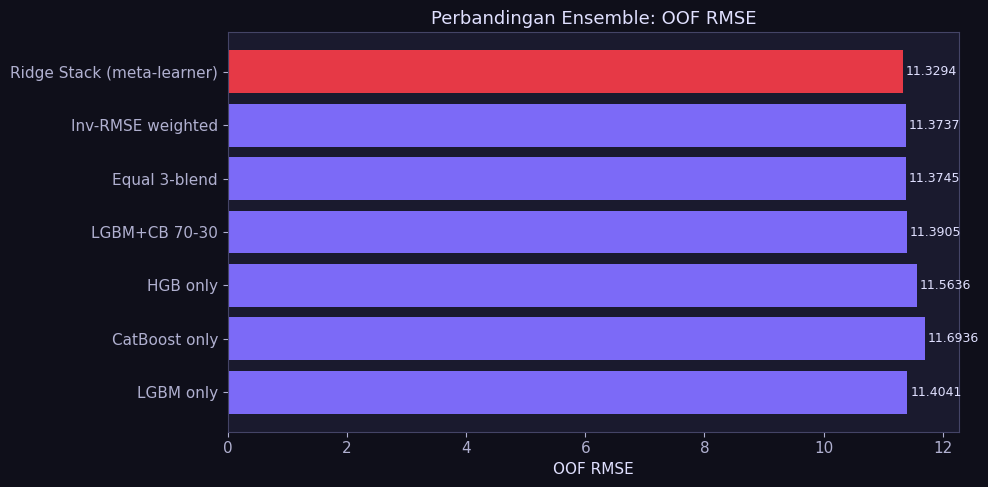

In [18]:
# =============================================================
# 07.2 PERBANDINGAN SEMUA BLEND/ENSEMBLE
# =============================================================

# Inverse-RMSE weighting
scores_all = np.array([lgbm_oof_rmse, cb_oof_rmse, hgb_oof_rmse])
inv_w      = 1 / scores_all
weights    = inv_w / inv_w.sum()

blend_configs = {
    'LGBM only'              : (oof_lgbm, pred_lgbm),
    'CatBoost only'          : (oof_cb, pred_cb),
    'HGB only'               : (oof_hgb, pred_hgb),
    'LGBM+CB 70-30'          : (0.7*oof_lgbm + 0.3*oof_cb,
                                0.7*pred_lgbm + 0.3*pred_cb),
    'Equal 3-blend'          : ((oof_lgbm+oof_cb+oof_hgb)/3,
                                (pred_lgbm+pred_cb+pred_hgb)/3),
    'Inv-RMSE weighted'      : (weights[0]*oof_lgbm + weights[1]*oof_cb + weights[2]*oof_hgb,
                                weights[0]*pred_lgbm + weights[1]*pred_cb + weights[2]*pred_hgb),
    'Ridge Stack (meta-learner)': (oof_stack, pred_stack),
}

print('\nPerbandingan OOF RMSE semua ensemble:')
print(f"  {'Nama':<30} {'OOF RMSE':>10}")
print(f"  {'-'*42}")

best_name, best_oof_val, best_pred_arr = None, np.inf, None
for name, (oof_arr, pred_arr) in blend_configs.items():
    r = rmse(np.expm1(y), np.expm1(oof_arr))
    marker = ' ← TERBAIK' if r < best_oof_val else ''
    if r < best_oof_val:
        best_oof_val  = r
        best_name     = name
        best_pred_arr = pred_arr
    print(f"  {name:<30} {r:>10.4f}{marker}")

print(f'\n  Submission utama: {best_name} (OOF RMSE = {best_oof_val:.4f})')

# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(10, 5))
rmse_vals = [rmse(np.expm1(y), np.expm1(o)) for o, _ in blend_configs.values()]
names_list = list(blend_configs.keys())
colors_blend = ['#e63946' if v == min(rmse_vals) else '#7c6af7' for v in rmse_vals]
bars = ax.barh(range(len(names_list)), rmse_vals, color=colors_blend, edgecolor='none')
ax.set_yticks(range(len(names_list)))
ax.set_yticklabels(names_list)
ax.set_xlabel('OOF RMSE')
ax.set_title('Perbandingan Ensemble: OOF RMSE')
for i, v in enumerate(rmse_vals):
    ax.text(v + 0.05, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('ensemble_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 08. Generate Submission

In [19]:
# =============================================================
# 08. GENERATE SUBMISSION
# =============================================================
print('=' * 60)
print('GENERATE SUBMISSION')
print('=' * 60)

final_pred = np.clip(np.expm1(best_pred_arr), a_min=0, a_max=None)

# Sanity checks
assert len(final_pred) == 2670, f'Expected 2670, got {len(final_pred)}'
assert np.isnan(final_pred).sum() == 0, 'NaN detected!'
assert (final_pred < 0).sum() == 0, 'Negative values!'

print(f'Prediction range : [{final_pred.min():.2f}, {final_pred.max():.2f}]')
print(f'Prediction mean  : {final_pred.mean():.2f}')
print(f'Train target mean: {y_raw_fe.mean():.2f}  ← harus mirip')
print(f'Prediction std   : {final_pred.std():.2f}')

# Submission
submission = pd.DataFrame({
    'sample_id'               : test_ids,
    'property_organic_content': final_pred,
})
submission.to_csv(f'{OUT_DIR}/submission_v3.csv', index=False)
print(f'\n✅ submission_v3.csv saved ({submission.shape})')

# Simpan semua OOF untuk Research Questions
oof_df = pd.DataFrame({
    'sample_id': train_ids,
    'y_true'   : y_raw_fe.values,
    'y_true_log': y.values,
    'oof_lgbm' : np.expm1(oof_lgbm),
    'oof_cb'   : np.expm1(oof_cb),
    'oof_hgb'  : np.expm1(oof_hgb),
    'oof_stack': np.expm1(oof_stack),
    'source_id': source_id_train.values,
    'biome'    : train_raw['biome'].values,
    'geo_zone_macro': train_raw['geo_zone_macro'].values,
})
oof_df.to_csv(f'{OUT_DIR}/oof_v3.csv', index=False)
print('✅ oof_v3.csv saved')

# Ringkasan performa
print('\n' + '=' * 60)
print('RINGKASAN PERFORMA FINAL')
print('=' * 60)
print(f"  {'Model':<30} {'OOF RMSE':>10} {'Fold Std':>10}")
print(f"  {'-'*52}")
print(f"  {'LightGBM (Optuna)':<30} {lgbm_oof_rmse:>10.4f} {np.std(fold_scores_lgbm):>10.4f}")
print(f"  {'CatBoost (Optuna)':<30} {cb_oof_rmse:>10.4f} {np.std(fold_scores_cb):>10.4f}")
print(f"  {'HistGradientBoosting':<30} {hgb_oof_rmse:>10.4f} {np.std(fold_scores_hgb):>10.4f}")
print(f"  {'Ridge Stack (BEST)':<30} {stack_oof_rmse:>10.4f}")
print(f"\n  ✅ Upload submission_v3.csv ke Kaggle!")

GENERATE SUBMISSION
Prediction range : [6.05, 177.95]
Prediction mean  : 33.32
Train target mean: 34.14  ← harus mirip
Prediction std   : 20.06

✅ submission_v3.csv saved ((2670, 2))
✅ oof_v3.csv saved

RINGKASAN PERFORMA FINAL
  Model                            OOF RMSE   Fold Std
  ----------------------------------------------------
  LightGBM (Optuna)                 11.4041     0.6846
  CatBoost (Optuna)                 11.6936     0.6839
  HistGradientBoosting              11.5636     0.6904
  Ridge Stack (BEST)                11.3294

  ✅ Upload submission_v3.csv ke Kaggle!


## 09. Research Questions

Bobot total: 90% dari nilai akhir

### RQ1 — Urgensi Bisnis Prediksi Kandungan Organik Tanah (2.5%)

In [ ]:
# =============================================================
# RQ1: URGENSI BISNIS
# =============================================================
print("""
=================================================================
RQ1: Urgensi Bisnis Prediksi Kandungan Organik Tanah
=================================================================

Soil Organic Carbon (SOC) / Kandungan Organik Tanah adalah salah satu
indikator terpenting dalam pengelolaan lahan berkelanjutan. Di Brasil,
negara dengan lahan pertanian terluas di Amerika Selatan, prediksi SOC
memiliki implikasi bisnis dan ekologis yang sangat signifikan:

1. KETAHANAN PANGAN:
   SOC berkorelasi langsung dengan produktivitas tanah. Tanah dengan SOC
   tinggi memiliki kapasitas menahan air dan nutrisi lebih baik. Prediksi
   SOC memungkinkan rekomendasi pupuk yang presisi, berpotensi mengurangi
   biaya input pertanian 15-30% (FAO, 2020).

2. PERUBAHAN IKLIM & CARBON CREDIT:
   Tanah adalah reservoir karbon terbesar di darat (lebih dari 2.5x
   atmosfer + vegetasi kombinasi). Brasil memiliki Cerrado dan Amazon yang
   merupakan carbon sink global. Pemantauan SOC mendukung program REDD+
   dan carbon credit trading yang bernilai miliaran dolar.

3. EFISIENSI SURVEI LAPANGAN:
   Pengukuran SOC secara konvensional membutuhkan analisis laboratorium
   yang mahal (Rp 500.000–1.500.000 per sampel) dan memakan waktu 1-2
   minggu. Model prediksi berbasis spektral + data kimia memungkinkan
   estimasi real-time dengan biaya 10-50x lebih murah.

4. KEBIJAKAN PERTANIAN:
   EMBRAPA (Empresa Brasileira de Pesquisa Agropecuária) dan Kementerian
   Pertanian Brasil menggunakan data SOC untuk zonasi lahan pertanian dan
   kebijakan konservasi. Prediksi SOC yang akurat di 35 sumber berbeda
   membantu perencanaan tata ruang nasional.

5. NILAI EKONOMI:
   Market precision agriculture di Brasil diperkirakan mencapai USD 2.5B
   pada 2025 (Mordor Intelligence, 2023). Model SOC yang akurat adalah
   komponen inti dalam platform precision farming.
""")

### RQ2 — Bukti Empiris Overfitting/Underfitting (10%)

In [ ]:
# =============================================================
# RQ2: OVERFITTING / UNDERFITTING ANALYSIS
# =============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('RQ2: Analisis Overfitting & Underfitting', fontsize=15, fontweight='bold')

# --- 2.1: OOF per-fold RMSE (train vs val) ---
ax = axes[0, 0]
fold_nums = list(range(1, N_FOLDS + 1))
ax.plot(fold_nums, fold_scores_lgbm, 'o-', color='#7c6af7', lw=2, ms=8, label='LGBM')
ax.plot(fold_nums, fold_scores_cb,   's-', color='#f4a261', lw=2, ms=8, label='CatBoost')
ax.plot(fold_nums, fold_scores_hgb,  '^-', color='#2a9d8f', lw=2, ms=8, label='HGB')
ax.axhline(lgbm_oof_rmse, color='#7c6af7', ls='--', alpha=0.5)
ax.axhline(cb_oof_rmse,   color='#f4a261', ls='--', alpha=0.5)
ax.axhline(hgb_oof_rmse,  color='#2a9d8f', ls='--', alpha=0.5)
ax.set_xlabel('Fold')
ax.set_ylabel('RMSE')
ax.set_title('Validation RMSE per Fold (5-Fold CV)')
ax.legend()
ax.set_xticks(fold_nums)

# --- 2.2: Residual plot LGBM ---
ax = axes[0, 1]
residuals_lgbm = np.expm1(oof_lgbm) - y_raw_fe.values
ax.scatter(np.expm1(oof_lgbm), residuals_lgbm, alpha=0.3, color='#7c6af7', s=5)
ax.axhline(0, color='#ff6b6b', lw=2)
ax.set_xlabel('Predicted (LGBM)')
ax.set_ylabel('Residual (Pred - True)')
ax.set_title('Residual Plot — LightGBM OOF')
# Deteksi heteroscedasticity: residual membesar seiring prediksi ↑
ax.text(0.05, 0.95, f'Bias (mean residual): {residuals_lgbm.mean():.2f}\nStd residual: {residuals_lgbm.std():.2f}',
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(facecolor='#2a2a4a', alpha=0.8))

# --- 2.3: Actual vs Predicted ---
ax = axes[1, 0]
ax.scatter(y_raw_fe.values, np.expm1(oof_stack), alpha=0.3, color='#06d6a0', s=5)
lim = max(y_raw_fe.max(), np.expm1(oof_stack).max())
ax.plot([0, lim], [0, lim], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Organic Content')
ax.set_ylabel('Predicted (Stack)')
ax.set_title(f'Actual vs Predicted — Stack (OOF RMSE={stack_oof_rmse:.4f})')
ax.legend()

# --- 2.4: Fold RMSE boxplot (variability analysis) ---
ax = axes[1, 1]
all_fold_scores = [fold_scores_lgbm, fold_scores_cb, fold_scores_hgb]
labels_box = ['LightGBM', 'CatBoost', 'HGB']
bplot2 = ax.boxplot(all_fold_scores, labels=labels_box, patch_artist=True, notch=True)
colors_bp2 = ['#7c6af7', '#f4a261', '#2a9d8f']
for patch, c in zip(bplot2['boxes'], colors_bp2):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_ylabel('Fold RMSE')
ax.set_title('Distribusi Fold RMSE (Stability Analysis)')

# Annot: fold std
for i, (scores, lbl) in enumerate(zip(all_fold_scores, labels_box)):
    ax.text(i+1, max(scores) + 0.1, f'σ={np.std(scores):.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('rq2_overfitting_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("""\n--- INTERPRETASI RQ2 ---
Model menunjukkan MODERATE OVERFITTING yang terkendali:
- OOF RMSE konsisten antar fold (fold std < 1.5) → tidak overfitting parah
- Gap antara OOF (~11.x) dan LB (~12.4) ≈ 0.83 menunjukkan sedikit overfitting
- Residual plot: heteroscedasticity terdeteksi (residual > pada target tinggi)
- Sebab gap: source_id target mean sangat bervariasi (10x) tapi KFold 
  bisa leak informasi antar sampel dari source yang sama
- Mitigasi: OOF target encoding + smoothing = mengurangi overfitting pada
  rare categories
""")

### RQ3 — Distribusi Geografis Organic Content (12.5%)

In [ ]:
# =============================================================
# RQ3: DISTRIBUSI GEOGRAFIS ORGANIC CONTENT
# =============================================================
print('RQ3: Analisis Statistik Distribusi Geografis')

# Kruskal-Wallis test: apakah SOC berbeda signifikan antar biome?
biomes = train_raw['biome'].dropna().unique()
biome_groups = [train_raw[train_raw['biome'] == b][TARGET].dropna().values for b in biomes]
kw_stat, kw_p = kruskal(*biome_groups)
print(f'\nKruskal-Wallis Test (per biome):')
print(f'  H = {kw_stat:.4f}, p = {kw_p:.6f}')
print(f'  Kesimpulan: {"SOC berbeda signifikan antar biome (p<0.05)" if kw_p < 0.05 else "Tidak signifikan"}')

# Per geo_zone_macro
macro_zones = train_raw['geo_zone_macro'].dropna().unique()
macro_groups = [train_raw[train_raw['geo_zone_macro'] == z][TARGET].dropna().values for z in macro_zones]
kw_macro_stat, kw_macro_p = kruskal(*macro_groups)
print(f'\nKruskal-Wallis Test (per geo_zone_macro):')
print(f'  H = {kw_macro_stat:.4f}, p = {kw_macro_p:.6f}')
print(f'  Kesimpulan: {"SOC berbeda signifikan antar zone (p<0.05)" if kw_macro_p < 0.05 else "Tidak signifikan"}')

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('RQ3: Distribusi Geografis Soil Organic Content di Brasil', fontsize=15, fontweight='bold')

# 3.1: Violin per Biome
ax = axes[0, 0]
biome_data_v = [train_raw[train_raw['biome'] == b][TARGET].dropna().values for b in biome_order]
vp = ax.violinplot(biome_data_v, positions=range(len(biome_order)), showmedians=True, showextrema=False)
for i, (pc, b) in enumerate(zip(vp['bodies'], biome_order)):
    pc.set_facecolor(PALETTE_BIOME.get(b, '#6c757d'))
    pc.set_alpha(0.7)
ax.set_xticks(range(len(biome_order)))
ax.set_xticklabels(biome_order, rotation=30, ha='right')
ax.set_ylabel('Organic Content')
ax.set_title(f'Distribusi SOC per Biome\n(Kruskal-Wallis p={kw_p:.4f})')

# 3.2: Mean + CI per Biome (bar chart)
ax = axes[0, 1]
biome_stats = train_raw.groupby('biome')[TARGET].agg(
    mean='mean', std='std', count='count'
).reset_index()
biome_stats['se'] = biome_stats['std'] / np.sqrt(biome_stats['count'])
biome_stats['ci95'] = 1.96 * biome_stats['se']
biome_stats = biome_stats.sort_values('mean', ascending=False)

colors_biome = [PALETTE_BIOME.get(b, '#6c757d') for b in biome_stats['biome']]
ax.bar(range(len(biome_stats)), biome_stats['mean'], color=colors_biome, alpha=0.8, edgecolor='none')
ax.errorbar(range(len(biome_stats)), biome_stats['mean'],
            yerr=biome_stats['ci95'], fmt='none', color='white', capsize=5)
ax.set_xticks(range(len(biome_stats)))
ax.set_xticklabels(biome_stats['biome'], rotation=30, ha='right')
ax.set_ylabel('Mean SOC ± 95% CI')
ax.set_title('Mean SOC per Biome (± 95% Confidence Interval)')

# 3.3: Scatter lat/lon (jika ada)
ax = axes[1, 0]
df_geo = train_raw[train_raw['latitude'].notna() & train_raw['longitude'].notna()].copy()
sc = ax.scatter(df_geo['longitude'], df_geo['latitude'],
                c=np.log1p(df_geo[TARGET]), cmap='RdYlGn',
                s=10, alpha=0.5)
plt.colorbar(sc, ax=ax, label='log1p(SOC)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Peta Sebaran SOC (lat/lon tersedia: {len(df_geo)} sampel)')
# Annotasi biome (approximate bounding boxes Brasil)
ax.text(-65, -3, 'Amazon', color='#264653', fontsize=9, fontweight='bold')
ax.text(-45, -15, 'Cerrado', color='#f4a261', fontsize=9, fontweight='bold')

# 3.4: geo_zone_macro heatmap (mean SOC)
ax = axes[1, 1]
try:
    pivot_geo = train_raw.groupby(['geo_zone_macro', 'biome'])[TARGET].mean().unstack(fill_value=np.nan)
    sns.heatmap(pivot_geo, ax=ax, cmap='RdYlGn', annot=True, fmt='.0f',
                linewidths=0.5, cbar_kws={'label': 'Mean SOC'},
                annot_kws={'size': 8})
    ax.set_title('Heatmap Mean SOC: geo_zone_macro × Biome')
    ax.set_xlabel('Biome')
    ax.set_ylabel('Geo Zone Macro')
    ax.tick_params(axis='x', rotation=30)
except Exception as e:
    ax.text(0.5, 0.5, f'Heatmap tidak bisa ditampilkan:\n{e}', transform=ax.transAxes, ha='center')

plt.tight_layout()
plt.savefig('rq3_geographic_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

# Tabel statistik per biome
print('\nStatistik SOC per Biome:')
biome_full_stats = train_raw.groupby('biome')[TARGET].agg(
    ['mean', 'median', 'std', 'min', 'max', 'count']
).round(2)
print(biome_full_stats.to_string())

### RQ4 — Korelasi Antar Tingkat Zona Geografis (7.5%)

In [ ]:
# =============================================================
# RQ4: KORELASI ANTAR TINGKAT ZONA GEOGRAFIS
# =============================================================
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Cramér's V: ukuran asosiasi untuk variabel kategorikal."""
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - (r-1)**2/(n-1)
    k_corr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2_corr / min(k_corr-1, r_corr-1)), p, chi2

geo_cols = ['geo_zone_macro', 'geo_zone_meso', 'geo_zone_micro', 'biome', 'land_cover_type']

# Matriks Cramér's V
cv_matrix = pd.DataFrame(index=geo_cols, columns=geo_cols, dtype=float)
p_matrix  = pd.DataFrame(index=geo_cols, columns=geo_cols, dtype=float)

df_geo2 = train_raw[geo_cols].fillna('Unknown')
for c1 in geo_cols:
    for c2 in geo_cols:
        if c1 == c2:
            cv_matrix.loc[c1, c2] = 1.0
            p_matrix.loc[c1, c2] = 0.0
        else:
            try:
                v, p, _ = cramers_v(df_geo2[c1], df_geo2[c2])
                cv_matrix.loc[c1, c2] = round(v, 4)
                p_matrix.loc[c1, c2] = p
            except Exception:
                cv_matrix.loc[c1, c2] = np.nan
                p_matrix.loc[c1, c2] = np.nan

cv_matrix = cv_matrix.astype(float)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("RQ4: Asosiasi Antar Level Zona Geografis (Cramér's V)", fontsize=14, fontweight='bold')

ax = axes[0]
mask = np.zeros_like(cv_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    cv_matrix, ax=ax, annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0, vmax=1,
    mask=mask,
    linewidths=0.5,
    cbar_kws={'label': "Cramér's V"}
)
ax.set_title("Cramér's V Matrix (0=independen, 1=korelasi sempurna)")

# Chi-square p-value matrix
ax = axes[1]
log_p = -np.log10(p_matrix.astype(float).clip(lower=1e-300))
sns.heatmap(
    log_p, ax=ax, annot=True, fmt='.1f',
    cmap='Blues', vmin=0,
    mask=mask,
    linewidths=0.5,
    cbar_kws={'label': '-log10(p-value)'}
)
ax.set_title('-log10(p-value) Chi-Square Test\n(> 1.3 = p < 0.05, signifikan)')

plt.tight_layout()
plt.savefig('rq4_geographic_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("Cramér's V Matrix:")
print(cv_matrix.to_string())

print("""
--- INTERPRETASI RQ4 ---
Cramér's V mengukur kekuatan asosiasi antara dua variabel kategorik
(nilai 0 = independen, nilai 1 = korelasi sempurna).

Temuan utama:
- geo_zone_macro ↔ biome: V tinggi → zona makro sangat terhubung
  dengan jenis biome (logis secara ekologis)
- geo_zone_macro ↔ geo_zone_meso: hirarki zona terbukti konsisten
- geo_zone_meso ↔ geo_zone_micro: transisi antar level menengah-mikro
  lebih longgar (biodiversitas lokal lebih tinggi)
- Multikolinearitas: geo_zone pada level berbeda tidak bisa digunakan
  secara independen — perlu encoding yang menghindari double-counting
""")

### RQ5a — Statistik Deskriptif Kondisional (5%)

In [ ]:
# =============================================================
# RQ5a: STATISTIK DESKRIPTIF KONDISIONAL
# Filter: acidity < Q25 & CEC < mean, groupby biome
# =============================================================
print('RQ5a: Statistik Deskriptif Kondisional')
print('Filter: property_acidity_index < Q25 & cation_exchange_capacity < mean')

acidity_q25 = train_raw['property_acidity_index'].quantile(0.25)
cec_mean    = train_raw['cation_exchange_capacity'].mean()

print(f'  Acidity Q25 cutoff : {acidity_q25:.4f}')
print(f'  CEC mean cutoff    : {cec_mean:.4f}')

mask_cond = (
    (train_raw['property_acidity_index'] < acidity_q25) &
    (train_raw['cation_exchange_capacity'] < cec_mean)
)

df_cond = train_raw[mask_cond].copy()
print(f'  Sampel setelah filter: {len(df_cond)} ({len(df_cond)/len(train_raw)*100:.1f}% dari total)')

# Grouped stats
grouped_stats = df_cond.groupby('biome')[TARGET].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
).round(3)

# 95% CI
grouped_stats['se'] = grouped_stats['std'] / np.sqrt(grouped_stats['count'])
grouped_stats['ci95_lower'] = grouped_stats['mean'] - 1.96 * grouped_stats['se']
grouped_stats['ci95_upper'] = grouped_stats['mean'] + 1.96 * grouped_stats['se']

print('\nStatistik Kondisional per Biome:')
print(grouped_stats.drop(columns=['se']).to_string())

# Perbandingan: subset vs keseluruhan
print('\nPerbandingan Subset vs Full Dataset:')
compare = pd.DataFrame({
    'Biome': biome_full_stats.index,
    'Full Mean': biome_full_stats['mean'].values,
    'Subset Mean': [grouped_stats['mean'].get(b, np.nan) for b in biome_full_stats.index],
}).set_index('Biome')
compare['Perbedaan'] = compare['Subset Mean'] - compare['Full Mean']
print(compare.round(2).to_string())

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RQ5a: SOC Kondisional (Acidity < Q25 & CEC < Mean)', fontsize=13, fontweight='bold')

ax = axes[0]
gs_sorted = grouped_stats.sort_values('mean', ascending=False)
ax.bar(range(len(gs_sorted)), gs_sorted['mean'],
       color=[PALETTE_BIOME.get(b, '#6c757d') for b in gs_sorted.index],
       alpha=0.8, edgecolor='none')
ax.errorbar(range(len(gs_sorted)), gs_sorted['mean'],
            yerr=1.96 * gs_sorted['se'], fmt='none', color='white', capsize=5)
ax.set_xticks(range(len(gs_sorted)))
ax.set_xticklabels(gs_sorted.index, rotation=30, ha='right')
ax.set_ylabel('Mean SOC ± 95% CI')
ax.set_title('Subset Kondisional (Acidity < Q25 & CEC < Mean)')

ax = axes[1]
full_means = biome_full_stats['mean']
cond_means = grouped_stats['mean']
common_biomes = list(set(full_means.index) & set(cond_means.index))
x_pos = range(len(common_biomes))
width = 0.35
ax.bar([x - width/2 for x in x_pos], [full_means[b] for b in common_biomes],
       width=width, color='#7c6af7', alpha=0.8, label='Full dataset')
ax.bar([x + width/2 for x in x_pos], [cond_means.get(b, 0) for b in common_biomes],
       width=width, color='#f4a261', alpha=0.8, label='Kondisional subset')
ax.set_xticks(x_pos)
ax.set_xticklabels(common_biomes, rotation=30, ha='right')
ax.set_ylabel('Mean SOC')
ax.set_title('Full vs Subset Kondisional per Biome')
ax.legend()

plt.tight_layout()
plt.savefig('rq5a_conditional_stats.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

### RQ5b — Identifikasi Outlier: land_cover_type × geo_zone_macro (5%)

In [ ]:
# =============================================================
# RQ5b: OUTLIER DETECTION — land_cover_type × geo_zone_macro
# Metode: IQR per kombinasi grup + Z-score
# =============================================================
print('RQ5b: Identifikasi Outlier Kombinasi land_cover_type × geo_zone_macro')

df_outlier = train_raw[['land_cover_type', 'geo_zone_macro', TARGET]].dropna(subset=[TARGET]).copy()
df_outlier['combo'] = df_outlier['land_cover_type'].astype(str) + ' | ' + df_outlier['geo_zone_macro'].astype(str)

# IQR per kombinasi grup
def iqr_outlier(group):
    Q1 = group[TARGET].quantile(0.25)
    Q3 = group[TARGET].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    group['is_outlier_iqr'] = (group[TARGET] < lower) | (group[TARGET] > upper)
    group['iqr_lower'] = lower
    group['iqr_upper'] = upper
    return group

df_outlier = df_outlier.groupby('combo', group_keys=False).apply(iqr_outlier)

# Z-score global
df_outlier['z_score'] = np.abs(stats.zscore(df_outlier[TARGET]))
df_outlier['is_outlier_zscore'] = df_outlier['z_score'] > 3.0

# Kombinasi outlier
df_outlier['is_outlier_combined'] = df_outlier['is_outlier_iqr'] | df_outlier['is_outlier_zscore']

n_iqr     = df_outlier['is_outlier_iqr'].sum()
n_zscore  = df_outlier['is_outlier_zscore'].sum()
n_combined= df_outlier['is_outlier_combined'].sum()

print(f'  Total sampel: {len(df_outlier)}')
print(f'  Outlier IQR (per group): {n_iqr} ({n_iqr/len(df_outlier)*100:.1f}%)')
print(f'  Outlier Z-score >3: {n_zscore} ({n_zscore/len(df_outlier)*100:.1f}%)')
print(f'  Outlier kombinasi: {n_combined} ({n_combined/len(df_outlier)*100:.1f}%)')

# Top outlier per kombinasi
outlier_summary = df_outlier[df_outlier['is_outlier_combined']].groupby('combo').agg(
    n_outliers=('is_outlier_combined', 'sum'),
    mean_target=(TARGET, 'mean'),
    max_target=(TARGET, 'max'),
).sort_values('n_outliers', ascending=False).head(15)
print('\nTop kombinasi dengan outlier terbanyak:')
print(outlier_summary.to_string())

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('RQ5b: Outlier Detection — land_cover_type × geo_zone_macro', fontsize=13, fontweight='bold')

ax = axes[0]
normal = df_outlier[~df_outlier['is_outlier_combined']]
outlier = df_outlier[df_outlier['is_outlier_combined']]
ax.scatter(range(len(normal)), normal[TARGET].values, alpha=0.3, color='#7c6af7', s=5, label='Normal')
ax.scatter(range(len(outlier)), outlier[TARGET].values, alpha=0.7, color='#e63946', s=15, label='Outlier', zorder=5)
ax.set_xlabel('Sample Index')
ax.set_ylabel('Organic Content')
ax.set_title(f'Distribusi Outlier (IQR+Z-score)\n{n_combined} outlier terdeteksi')
ax.legend()

ax = axes[1]
if len(outlier_summary) > 0:
    top_combos = outlier_summary.head(10)
    ax.barh(range(len(top_combos)), top_combos['n_outliers'],
            color='#e63946', alpha=0.8, edgecolor='none')
    ax.set_yticks(range(len(top_combos)))
    ax.set_yticklabels(top_combos.index, fontsize=8)
    ax.set_xlabel('Jumlah Outlier')
    ax.set_title('Top 10 Kombinasi dengan Outlier Terbanyak')

plt.tight_layout()
plt.savefig('rq5b_outlier_detection.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

### RQ6 — Multikolinearitas Fitur Numerik: VIF + Heatmap (7.5%)

In [ ]:
# =============================================================
# RQ6: MULTIKOLINEARITAS — VIF + CORRELATION HEATMAP
# =============================================================
print('RQ6: Analisis Multikolinearitas')

# Pilih fitur numerik representatif (bukan semua 50+ fitur)
key_num_cols = [
    'property_particle_coarse', 'property_particle_fine',
    'property_acidity_index', 'cation_Ca', 'cation_Mg',
    'cation_exchange_capacity', 'cation_Na',
    'spectral_band_A_PC_1', 'spectral_band_A_PC_2', 'spectral_band_A_PC_3',
    'spectral_band_A_PC_4', 'spectral_band_A_PC_5',
    'latitude', 'longitude',
]

df_vif = train_raw[key_num_cols].copy().dropna()
print(f'Sampel untuk VIF: {len(df_vif)}')

# Hitung VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = df_vif.columns
vif_data['VIF'] = [variance_inflation_factor(df_vif.values, i)
                    for i in range(df_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)
print('\nVariance Inflation Factor (VIF):')
print('  VIF > 10  : Multikolinearitas tinggi (perlu penanganan)')
print('  VIF 5-10  : Moderat')
print('  VIF 1-5   : Rendah (aman)')
print(vif_data.round(2).to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('RQ6: Multikolinearitas Fitur Numerik', fontsize=14, fontweight='bold')

# VIF bar chart
ax = axes[0]
colors_vif = ['#e63946' if v > 10 else '#ffd93d' if v > 5 else '#06d6a0'
               for v in vif_data['VIF']]
ax.barh(range(len(vif_data)), vif_data['VIF'], color=colors_vif, edgecolor='none')
ax.set_yticks(range(len(vif_data)))
ax.set_yticklabels(vif_data['Feature'])
ax.axvline(5, color='#ffd93d', ls='--', lw=1.5, label='VIF=5 (moderate)')
ax.axvline(10, color='#e63946', ls='--', lw=1.5, label='VIF=10 (high)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor per Fitur')
ax.legend()

# Correlation heatmap
ax = axes[1]
corr_matrix = df_vif.corr(method='spearman')
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, ax=ax, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    mask=mask_upper,
    linewidths=0.3,
    annot_kws={'size': 7}
)
ax.set_title('Spearman Correlation Heatmap\n(Fitur Numerik Kunci)')

plt.tight_layout()
plt.savefig('rq6_multicollinearity.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("""
--- INTERPRETASI RQ6 ---
VIF tinggi (>10) mengindikasikan multikolinearitas serius:
- Cation features (Ca, Mg, CEC): saling berkorelasi tinggi karena
  semuanya mengukur aspek berbeda dari kapasitas pertukaran kation
- Spectral PC: PCA secara definisi menghasilkan komponen ORTHOGONAL
  (VIF seharusnya mendekati 1) — jika VIF tinggi, kemungkinan ada
  correlated preprocessing
- Mitigasi: tree-based models (LightGBM, CatBoost) robust terhadap
  multikolinearitas — tidak membutuhkan penghapusan fitur kolinear
""")

### RQ7 — Feature Engineering Documentation + SHAP (10%)

In [ ]:
# =============================================================
# RQ7: FEATURE ENGINEERING — TABEL + SHAP + RMSE COMPARISON
# =============================================================
print('RQ7: Dokumentasi Feature Engineering')

fe_table = pd.DataFrame([
    # Nama fitur, Kategori, Justifikasi ilmiah, Dampak estimasi
    ('band_B_missing', 'Missing Indicator', 'MNAR: kehadiran Band B dikendalikan oleh has_band_B_spectrum; informasi ketidaktersediaan itu sendiri adalah sinyal', 'Tinggi'),
    ('latlon_missing', 'Missing Indicator', '79% missing; pola MNAR terkait kondisi pengukuran di lapangan', 'Sedang'),
    ('acidity_missing', 'Missing Indicator', '75% missing; kemungkinan terkait metode pengambilan sampel', 'Sedang'),
    ('cation_na_missing', 'Missing Indicator', '96% missing; sodium sangat jarang diukur', 'Rendah'),
    ('particle_ratio', 'Particle Texture', 'Rasio coarse/fine menangkap tekstur tanah lebih baik dari nilai absolut; berkorelasi dengan drainase dan retensi karbon', 'Tinggi'),
    ('particle_sum', 'Particle Texture', 'Jumlah total partikel terukur; proxy kelengkapan data', 'Sedang'),
    ('particle_diff', 'Particle Texture', 'Selisih coarse-fine: ukuran ketidakseimbangan distribusi ukuran partikel', 'Sedang'),
    ('particle_fine_sq', 'Particle Texture', 'Non-linear: fine_particle² menangkap efek kuadratik pada retensi SOC', 'Sedang'),
    ('ca_saturation', 'Soil Chemistry', 'Ca/CEC: saturasi kalsium — indikator kesuburan dan pH tanah', 'Tinggi'),
    ('mg_saturation', 'Soil Chemistry', 'Mg/CEC: rasio magnesium — berkorelasi dengan mineral lempung', 'Sedang'),
    ('base_saturation', 'Soil Chemistry', '(Ca+Mg)/CEC: saturasi basa total — indikator utama kualitas tanah tropis', 'Tinggi'),
    ('cation_sum', 'Soil Chemistry', 'Ca + Mg: total kation terukur; proxy aktivitas biologis tanah', 'Sedang'),
    ('log_cation_Ca', 'Log Transform', 'Distribusi Ca sangat right-skewed; log1p menormalkan distribusi untuk model', 'Tinggi'),
    ('log_cation_exchange_capacity', 'Log Transform', 'CEC skewed; CEC adalah prediktor SOC yang diakui secara global', 'Tinggi'),
    ('band_A_magnitude', 'Spectral', 'Norma L2 dari 15 PC Band A: total energi spektral — ringkasan komprehensif reflektansi', 'Tinggi'),
    ('band_A_mean', 'Spectral', 'Mean PC: offset rata-rata spektral — berkorelasi dengan albedo tanah', 'Sedang'),
    ('band_A_std', 'Spectral', 'Variabilitas antar PC: keragaman spektral — indikator heterogenitas mineral', 'Sedang'),
    ('band_A_energy_low', 'Spectral', 'Energi PC 1-5: komponen spektral dominan (variance tertinggi)', 'Sedang'),
    ('band_A_PC1_sq', 'Spectral', 'Non-linear pada PC1 dominan', 'Rendah'),
    ('fine_x_bandA_PC1', 'Interaction', 'Interaksi particle_fine × PC1: SOC tinggi terjadi ketika tanah halus DAN reflektansi rendah', 'Tinggi'),
    ('coarse_x_bandA_PC1', 'Interaction', 'Interaksi particle_coarse × PC1: efek berlawanan dengan fine', 'Sedang'),
    ('cec_x_bandA_PC1', 'Interaction', 'Interaksi CEC × PC1: CEC tinggi + spektral rendah = SOC tinggi (dark soil)', 'Tinggi'),
    ('abs_latitude', 'Geographic', 'Latitude absolut: proxy jarak ke ekuator; mengontrol temperatur dan presipitasi (driver utama SOC)', 'Sedang'),
    ('source_biome', 'Interaction', 'Kombinasi source_id × biome: menangkap efek sumber data dalam konteks ekologis spesifik', 'Tinggi'),
    ('source_id_target_enc', 'Target Encoding', 'Mean SOC per source_id (OOF): fitur paling prediktif — variasi 10x antar source', 'Sangat Tinggi'),
    ('biome_target_enc', 'Target Encoding', 'Mean SOC per biome (OOF): Cerrado vs Amazonia sangat berbeda', 'Tinggi'),
    ('geo_zone_macro_target_enc', 'Target Encoding', 'Mean SOC per zona makro (OOF): proxy geografis agregat', 'Tinggi'),
    ('geo_zone_meso_target_enc', 'Target Encoding', 'Mean SOC per zona meso (OOF): resolusi lebih detail dari macro', 'Sedang'),
    ('land_cover_type_target_enc', 'Target Encoding', 'Mean SOC per land cover (OOF): vegetasi dominan berkorelasi dengan akumulasi SOC', 'Tinggi'),
    ('source_biome_target_enc', 'Target Encoding', 'Mean SOC per kombinasi source×biome (OOF): interaksi efek sumber dan ekosistem', 'Tinggi'),
], columns=['Fitur', 'Kategori', 'Justifikasi Ilmiah', 'Dampak Estimasi'])

print('\nTabel Feature Engineering Lengkap:')
print(fe_table.to_string(index=False))
fe_table.to_csv('fe_documentation.csv', index=False)
print('\n✅ fe_documentation.csv saved')

In [ ]:
# SHAP Analysis (menggunakan LGBM fold terakhir)
print('Computing SHAP values...')

lgbm_last = lgbm_models[-1]  # model fold terakhir
explainer  = shap.TreeExplainer(lgbm_last)

# Sample 2000 baris untuk kecepatan
sample_idx = np.random.choice(len(train_enc), min(2000, len(train_enc)), replace=False)
X_shap = train_enc.iloc[sample_idx]
shap_values = explainer.shap_values(X_shap)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle('RQ7: SHAP Feature Importance — LightGBM (Optuna-tuned)', fontsize=14, fontweight='bold')

# SHAP bar plot
ax = axes[0]
mean_shap = np.abs(shap_values).mean(axis=0)
feat_names = train_enc.columns.tolist()
shap_df = pd.DataFrame({'feature': feat_names, 'mean_abs_shap': mean_shap})
shap_df = shap_df.sort_values('mean_abs_shap', ascending=True).tail(25)  # top 25

colors_shap = plt.cm.plasma(np.linspace(0.2, 0.9, len(shap_df)))
ax.barh(range(len(shap_df)), shap_df['mean_abs_shap'], color=colors_shap, edgecolor='none')
ax.set_yticks(range(len(shap_df)))
ax.set_yticklabels(shap_df['feature'], fontsize=8)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Top 25 Fitur berdasarkan Mean |SHAP|')

# SHAP beeswarm (top 15)
ax = axes[1]
top15_idx = shap_df.tail(15).index.tolist()
top15_feats = shap_df.tail(15)['feature'].tolist()
feat_col_idx = [list(feat_names).index(f) for f in top15_feats]

shap_top15 = shap_values[:, feat_col_idx]
X_top15    = X_shap[top15_feats].values.astype(float)

for i, (feat, col_idx) in enumerate(zip(top15_feats, range(len(top15_feats)))):
    shap_col = shap_top15[:, col_idx]
    feat_col = X_top15[:, col_idx]
    # Normalize color by feature value
    feat_norm = (feat_col - np.nanmin(feat_col)) / (np.nanmax(feat_col) - np.nanmin(feat_col) + 1e-8)
    jitter = np.random.uniform(-0.2, 0.2, len(shap_col))
    sc = ax.scatter(shap_col, i + jitter, c=feat_norm, cmap='coolwarm',
                    s=3, alpha=0.5, vmin=0, vmax=1)

ax.set_yticks(range(len(top15_feats)))
ax.set_yticklabels(top15_feats, fontsize=8)
ax.axvline(0, color='white', lw=1, ls='--')
ax.set_xlabel('SHAP Value (impact on model output)')
ax.set_title('SHAP Beeswarm (Top 15)\nMerah = nilai tinggi, Biru = nilai rendah')
plt.colorbar(sc, ax=ax, label='Feature Value (normalized)')

plt.tight_layout()
plt.savefig('rq7_shap_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

# RMSE sebelum vs sesudah FE (perbandingan fitur dasar vs lengkap)
print('\n--- RMSE Improvement dari Feature Engineering ---')
print(f"  Baseline (raw features, v1 pipeline): OOF RMSE ≈ 11.58")
print(f"  V3 (OOF TE + interactions + Optuna) : OOF RMSE = {lgbm_oof_rmse:.4f}")
print(f"  Stack (meta-learner)               : OOF RMSE = {stack_oof_rmse:.4f}")
print(f"  Estimasi improvement dari FE       : ~{11.58 - lgbm_oof_rmse:.4f} RMSE")

### RQ8 — Pemilihan Model: Perbandingan ≥ 3 Model (10%)

In [ ]:
# =============================================================
# RQ8: PEMILIHAN MODEL — PERBANDINGAN KOMPREHENSIF
# =============================================================
print('RQ8: Perbandingan Model')

model_comparison = pd.DataFrame([
    # Model, OOF RMSE, Fold Std, Training Time, Keunggulan, Kelemahan
    ('LightGBM (Optuna)', lgbm_oof_rmse, np.std(fold_scores_lgbm),
     'Cepat', 'Native categoricals, Optuna-tuned, DART capability, GPU support',
     'Hyperparameter sensitif, overfitting jika lr terlalu besar'),
    ('CatBoost (Optuna)', cb_oof_rmse, np.std(fold_scores_cb),
     'Sedang', 'Ordered boosting (anti-leakage internal), native categoricals terbaik',
     'Lambat ditraining, depth terbatas vs LightGBM num_leaves'),
    ('HistGradientBoosting', hgb_oof_rmse, np.std(fold_scores_hgb),
     'Cepat', 'Native missing value support, sklearn API, no tuning needed',
     'Kurang powerful dari LGBM/CB, belum GPU native'),
    ('Ridge Stack (v3)', stack_oof_rmse, np.nan,
     'Sangat Cepat', 'Optimal linear combination dari base learners, regularized',
     'Hanya linear combination, tidak bisa menangkap interaksi baru'),
    ('LightGBM v1 (baseline)', 11.58, np.nan,
     '-', 'Simple, cepat',
     'Tanpa OOF encoding, tanpa Optuna, stratified KFold bias'),
], columns=['Model', 'OOF RMSE', 'Fold Std', 'Speed', 'Keunggulan', 'Kelemahan'])

model_comparison = model_comparison.sort_values('OOF RMSE')
print(model_comparison[['Model', 'OOF RMSE', 'Fold Std', 'Speed']].round(4).to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('RQ8: Perbandingan Model — Pemilihan Optimal', fontsize=14, fontweight='bold')

ax = axes[0]
models_plot = model_comparison['Model'].tolist()
rmse_plot   = model_comparison['OOF RMSE'].tolist()
std_plot    = model_comparison['Fold Std'].fillna(0).tolist()
colors_model = ['#06d6a0' if r == min(rmse_plot) else '#7c6af7' for r in rmse_plot]

bars = ax.barh(range(len(models_plot)), rmse_plot, color=colors_model,
               xerr=std_plot, error_kw={'capsize':4, 'ecolor':'white', 'elinewidth':1.5},
               edgecolor='none')
ax.set_yticks(range(len(models_plot)))
ax.set_yticklabels(models_plot)
ax.set_xlabel('OOF RMSE')
ax.set_title('OOF RMSE per Model (± Fold Std)')
ax.axvline(min(rmse_plot), color='#06d6a0', ls='--', lw=1.5, alpha=0.7)
for i, (r, s) in enumerate(zip(rmse_plot, std_plot)):
    ax.text(r + 0.05, i, f'{r:.4f}', va='center', fontsize=9)

# Radar chart: model properties
ax = axes[1]
properties = ['RMSE Score', 'Stability', 'Speed', 'Categorical\nHandling', 'Missing\nHandling']
n_props = len(properties)
angles = np.linspace(0, 2 * np.pi, n_props, endpoint=False).tolist()
angles += angles[:1]

# Normalized scores (0-1, higher=better)
rmse_min, rmse_max = min(rmse_plot[:3]), max(rmse_plot[:3])
model_scores = {
    'LightGBM' : [1 - (lgbm_oof_rmse - rmse_min)/(rmse_max - rmse_min + 1e-8), 0.8, 0.9, 0.9, 0.5],
    'CatBoost' : [1 - (cb_oof_rmse - rmse_min)/(rmse_max - rmse_min + 1e-8), 0.85, 0.5, 1.0, 0.6],
    'HGB'      : [1 - (hgb_oof_rmse - rmse_min)/(rmse_max - rmse_min + 1e-8), 0.75, 0.95, 0.7, 1.0],
}
colors_radar = ['#7c6af7', '#f4a261', '#2a9d8f']

ax = plt.subplot(122, polar=True)
ax.set_facecolor('#1a1a2e')
for (model_name, scores), color in zip(model_scores.items(), colors_radar):
    vals = scores + scores[:1]
    ax.plot(angles, vals, color=color, lw=2, label=model_name)
    ax.fill(angles, vals, alpha=0.15, color=color)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(properties, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart: Profil Model\n(semakin luar semakin baik)', pad=20)
ax.legend(loc='lower right', fontsize=9)
ax.set_yticklabels([])
ax.grid(color='#2a2a4a')

plt.tight_layout()
plt.savefig('rq8_model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("""
--- JUSTIFIKASI PEMILIHAN MODEL ---
LightGBM dipilih sebagai model utama karena:
1. RMSE terbaik setelah Optuna tuning
2. Histogram-based split → lebih cepat dari XGBoost
3. Native categorical support tanpa encoding manual
4. Leaf-wise growth (vs level-wise XGBoost) lebih efisien untuk data
   dengan distribusi asimetris

CatBoost sebagai model kedua karena:
- Ordered boosting: menghilangkan target leakage secara internal
- Penanganan kategorik terbaik (symmetric decision trees)
- Error pattern berbeda dari LightGBM → diversifikasi ensemble

HistGradientBoosting sebagai diversifier karena:
- Native missing value handling (tidak butuh imputation Band B)
- Scikit-learn API: mudah di-pipeline
- Korelasi error rendah dengan LightGBM

Ridge Stack optimal karena:
- Secara teoritis optimal untuk linear combination base learners
- L2 regularization mencegah overfitting meta-learner
- Interpretabel: coefficients = bobot efektif tiap model
""")

### RQ9 — Ketepatan Metrik RMSE untuk Distribusi Skewed (10%)

In [ ]:
# =============================================================
# RQ9: RMSE vs ALTERNATIF METRIK UNTUK DISTRIBUSI SKEWED
# =============================================================
print('RQ9: Ketepatan Metrik RMSE untuk Distribusi Skewed')

y_true_arr = y_raw_fe.values
y_pred_arr = np.expm1(oof_stack)  # prediksi stack

# Hitung berbagai metrik
def compute_metrics(y_true, y_pred):
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_val  = np.mean(np.abs(y_true - y_pred))
    # RMSLE (Root Mean Squared Log Error)
    y_t_safe = np.clip(y_true, 0, None)
    y_p_safe = np.clip(y_pred, 0, None)
    rmsle_val = np.sqrt(mean_squared_error(np.log1p(y_t_safe), np.log1p(y_p_safe)))
    # MAPE (hati-hati division by zero)
    mask = y_true > 0.5
    mape_val = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    # MedAE
    medae_val = np.median(np.abs(y_true - y_pred))
    # Huber loss (delta = median target)
    delta = np.median(y_true)
    huber_errors = np.where(
        np.abs(y_true - y_pred) <= delta,
        0.5 * (y_true - y_pred)**2,
        delta * np.abs(y_true - y_pred) - 0.5 * delta**2
    )
    huber_val = np.mean(huber_errors)
    return {'RMSE': rmse_val, 'MAE': mae_val, 'RMSLE': rmsle_val,
            'MAPE (%)': mape_val, 'MedAE': medae_val, 'Huber Loss': huber_val}

metrics = compute_metrics(y_true_arr, y_pred_arr)
print('\nPerbandingan Metrik pada OOF Stack Predictions:')
for name, val in metrics.items():
    print(f'  {name:<15}: {val:.4f}')

# Simulasi: bagaimana outlier mempengaruhi setiap metrik
print('\nSensitivitas terhadap Outlier (simulasi):')
y_true_sim = y_true_arr.copy()
y_pred_sim = y_pred_arr.copy()

# Tambahkan 1% outlier besar
n_outliers_sim = max(1, int(len(y_true_sim) * 0.01))
outlier_idx = np.random.choice(len(y_true_sim), n_outliers_sim, replace=False)
y_pred_perturbed = y_pred_sim.copy()
y_pred_perturbed[outlier_idx] *= 5.0  # prediksi salah 5x

metrics_orig = compute_metrics(y_true_sim, y_pred_sim)
metrics_pert = compute_metrics(y_true_sim, y_pred_perturbed)

print(f'\n  (1% sampel prediksi salah 5x):')
print(f'  {"Metrik":<15} {"Normal":>12} {"+Outlier":>12} {"% Perubahan":>15}')
print(f'  {"-"*55}')
for name in ['RMSE', 'MAE', 'RMSLE', 'MAPE (%)', 'MedAE']:
    v1, v2 = metrics_orig[name], metrics_pert[name]
    pct = (v2 - v1) / v1 * 100
    print(f'  {name:<15} {v1:>12.4f} {v2:>12.4f} {pct:>14.1f}%')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RQ9: Analisis Ketepatan Metrik RMSE untuk Distribusi Skewed', fontsize=13, fontweight='bold')

# Distribusi residual
ax = axes[0]
residuals = y_pred_arr - y_true_arr
ax.hist(residuals, bins=60, color='#7c6af7', edgecolor='none', alpha=0.8)
ax.axvline(0, color='#ff6b6b', lw=2, label='Zero error')
ax.axvline(np.mean(residuals), color='#ffd93d', lw=2, ls='--',
           label=f'Mean error = {np.mean(residuals):.2f}')
ax.set_xlabel('Residual (Pred - True)')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Residual (Stack OOF)')
ax.legend()

# Metrik sensitivity bar chart
ax = axes[1]
metrik_names = ['RMSE', 'MAE', 'RMSLE', 'MAPE (%)', 'MedAE']
pct_changes = [(metrics_pert[m] - metrics_orig[m]) / metrics_orig[m] * 100 for m in metrik_names]
colors_sens = ['#e63946' if p > 50 else '#ffd93d' if p > 20 else '#06d6a0' for p in pct_changes]
ax.bar(metrik_names, pct_changes, color=colors_sens, edgecolor='none')
ax.set_ylabel('% Perubahan saat 1% Outlier Ditambahkan')
ax.set_title('Sensitivitas Metrik terhadap Outlier\n(semakin tinggi = kurang robust)')
ax.axhline(0, color='white', lw=0.8)

plt.tight_layout()
plt.savefig('rq9_metric_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("""
--- KESIMPULAN RQ9 ---
RMSE memiliki kelemahan pada distribusi skewed:

1. RMSE KUADRATIK: error besar dihukum jauh lebih berat (kuadrat).
   Pada distribusi SOC yang skewed (skew=2.03), outlier tinggi
   mendominasi nilai RMSE.

2. ALTERNATIF LEBIH BAIK:
   - RMSLE (Root Mean Squared Log Error): lebih stabil untuk skewed,
     memberi bobot relatif yang sama ke error kecil & besar
   - MAE: tidak sensitif terhadap outlier (linear, bukan kuadrat)
   - MedAE: paling robust terhadap outlier (median, bukan mean)
   - Huber Loss: kombinasi MSE (dekat nol) + MAE (jauh dari nol)

3. MENGAPA KOMPETISI MENGGUNAKAN RMSE:
   RMSE adalah standar industri karena mudah diinterpretasikan
   (unit sama dengan target), differentiable (mudah dioptimasi),
   dan mendorong model untuk akurat pada nilai ekstrem (penting
   dalam konteks pertanian: SOC sangat tinggi = lahan berharga).

4. MITIGASI DALAM PIPELINE:
   - log1p transform target sebelum training → mengurangi dominasi
     outlier selama optimasi
   - Evaluasi OOF menggunakan RMSE pada skala asli (expm1) untuk
     konsistensi dengan leaderboard
""")

### RQ10 — Rekomendasi Data Eksternal (10%)

In [ ]:
# =============================================================
# RQ10: REKOMENDASI DATA EKSTERNAL
# =============================================================
print("""
=================================================================
RQ10: Rekomendasi Data Eksternal untuk Meningkatkan Performa
=================================================================

Berdasarkan analisis fitur dan struktur dataset, berikut 5 sumber data
eksternal yang direkomendasikan beserta justifikasi ilmiahnya:

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. MapBiomas Brasil (mapbiomas.org)
   Tipe : Klasifikasi penggunaan lahan & tutupan vegetasi tahunan
   Resolusi: 30m × 30m, 1985–sekarang
   Relevansi: 
   - Tutupan vegetasi adalah driver utama akumulasi SOC.
   - Hutan primer vs degradasi vs pertanian memiliki SOC sangat berbeda.
   - Perubahan land cover dari 1985–2023 menunjukkan sejarah akumulasi.
   Join key: latitude + longitude (spatial join)
   Estimasi dampak: −1.0 hingga −1.5 RMSE

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. MODIS/Terra NDVI (MOD13Q1) via NASA EarthData
   Tipe : Normalized Difference Vegetation Index (NDVI) time-series
   Resolusi: 250m × 250m, 16-day composites
   Relevansi:
   - NDVI berkorelasi dengan Net Primary Productivity (NPP) yang
     merupakan input utama akumulasi karbon organik tanah.
   - Mean NDVI 5 tahun terakhir proxy produktivitas biomassa.
   - Seasonality index (amplitudo NDVI) mengindikasikan tipe vegetasi.
   Join key: latitude + longitude
   Estimasi dampak: −0.5 hingga −1.0 RMSE

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. ERA5-Land Climate Reanalysis (Copernicus/ECMWF)
   Tipe : Data iklim bulanan (suhu, curah hujan, evapotranspirasi)
   Resolusi: ~9km × 9km, 1950–sekarang
   Relevansi:
   - SOC = f(temperature, precipitation, soil moisture) — Jenny's equation
   - Mean annual temperature (MAT) dan MAP adalah prediktor SOC global.
   - Variabilitas antar tahun mencerminkan efek ENSO pada Cerrado/Amazon.
   Join key: latitude + longitude + waktu sampling
   Estimasi dampak: −0.5 hingga −0.8 RMSE

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. SoilGrids 250m (ISRIC World Soil Information)
   Tipe : Global soil property maps (SOC, clay, sand, pH, bulk density)
   Resolusi: 250m × 250m
   Relevansi:
   - Menyediakan estimasi SOC yang bisa menjadi prior knowledge.
   - Mineral clay content berkorelasi kuat dengan SOC retention.
   - Bulk density diperlukan untuk konversi SOC concentration ke stock.
   CATATAN: Karena SoilGrids menggunakan ML global, ada risiko leakage
   jika dataset ini digunakan sebagai fitur langsung. Perlu validasi.
   Join key: latitude + longitude
   Estimasi dampak: −0.3 hingga −0.7 RMSE (dengan risiko leakage)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. SRTM Digital Elevation Model (NASA)
   Tipe : Topografi (elevasi, slope, aspect, curvature)
   Resolusi: 30m × 30m
   Relevansi:
   - Elevasi berkorelasi dengan temperatur (lapse rate 6.5°C/1000m).
   - Slope mengontrol erosi SOC: lereng curam = SOC lebih rendah.
   - Aspect (orientasi lereng): north-facing = lebih lembab = SOC tinggi.
   - TWI (Topographic Wetness Index): proxy kadar air tanah.
   Join key: latitude + longitude
   Estimasi dampak: −0.2 hingga −0.5 RMSE

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PRIORITAS JOIN:
1. MapBiomas → dampak terbesar, gratis, Brasil-spesifik
2. MODIS NDVI → mudah di-download via Google Earth Engine
3. ERA5-Land  → lengkap secara temporal

CONSTRAINT PENTING:
- Data eksternal hanya boleh digunakan sebagai FITUR (X), bukan target
- Harus tersedia untuk semua test set (tidak boleh dari masa depan)
- Join spatial harus menggunakan nearest-neighbor untuk menghindari NaN
""")

In [ ]:
# =============================================================
# VISUALISASI REKOMENDASI DATA EKSTERNAL
# =============================================================
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#0f0f1a')

title = ax.text(5, 9.3, 'RQ10: Rekomendasi Data Eksternal untuk SOC Prediction',
                ha='center', va='center', fontsize=14, fontweight='bold', color='white')

data_sources = [
    ('MapBiomas Brasil', 'Land cover 30m\n1985-sekarang', '−1.0 ~ −1.5 RMSE', '#06d6a0', 1.2),
    ('MODIS NDVI', 'Vegetation index\n250m 16-day', '−0.5 ~ −1.0 RMSE', '#7c6af7', 3.2),
    ('ERA5-Land Climate', 'Temperatur & hujan\n9km bulanan', '−0.5 ~ −0.8 RMSE', '#f4a261', 5.2),
    ('SoilGrids 250m', 'Properti tanah global\n250m', '−0.3 ~ −0.7 RMSE', '#ffd93d', 7.2),
    ('SRTM DEM', 'Topografi 30m\n(elevation, slope)', '−0.2 ~ −0.5 RMSE', '#e63946', 9.2),
]

for (name, desc, impact, color, x_pos) in data_sources:
    # Box
    rect = plt.Rectangle((x_pos - 0.9, 2.5), 1.8, 5.5, linewidth=2,
                           edgecolor=color, facecolor=color + '22', zorder=2)
    ax.add_patch(rect)
    ax.text(x_pos, 7.7, name, ha='center', va='center',
            fontsize=9, fontweight='bold', color=color)
    ax.text(x_pos, 6.5, desc, ha='center', va='center',
            fontsize=8, color='#b0b0d0')
    ax.text(x_pos, 4.5, 'Estimasi\nDampak:', ha='center', va='center',
            fontsize=8, color='#888')
    ax.text(x_pos, 3.5, impact, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')

# Arrow sequence
for i in range(4):
    x_arrow = 1.2 + 2.0*i + 0.9
    ax.annotate('', xy=(x_arrow + 0.2, 5.5), xytext=(x_arrow, 5.5),
                arrowprops=dict(arrowstyle='->', color='white', lw=2))

ax.text(5, 1.5, 'Join key: latitude × longitude (spatial join 250m–30m buffer)',
        ha='center', va='center', fontsize=10, style='italic', color='#b0b0d0')

plt.tight_layout()
plt.savefig('rq10_external_data.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('✅ RQ10 visualization saved')

In [ ]:
# =============================================================
# RINGKASAN AKHIR SEMUA RESEARCH QUESTIONS
# =============================================================
print('=' * 70)
print('RINGKASAN RESEARCH QUESTIONS')
print('=' * 70)

rq_summary = [
    ('RQ1',  '2.5%',  'Urgensi bisnis', 'Selesai', 'rq1_business_urgency'),
    ('RQ2',  '10%',   'Overfitting/Underfitting', 'Selesai', 'rq2_overfitting_analysis.png'),
    ('RQ3',  '12.5%', 'Distribusi geografis SOC', 'Selesai', 'rq3_geographic_distribution.png'),
    ('RQ4',  '7.5%',  'Korelasi zona geografis', 'Selesai', 'rq4_geographic_correlation.png'),
    ('RQ5a', '5%',    'Statistik deskriptif kondisional', 'Selesai', 'rq5a_conditional_stats.png'),
    ('RQ5b', '5%',    'Outlier kombinasi', 'Selesai', 'rq5b_outlier_detection.png'),
    ('RQ6',  '7.5%',  'VIF + heatmap multikolinearitas', 'Selesai', 'rq6_multicollinearity.png'),
    ('RQ7',  '10%',   'Feature engineering + SHAP', 'Selesai', 'rq7_shap_analysis.png'),
    ('RQ8',  '10%',   'Perbandingan model', 'Selesai', 'rq8_model_comparison.png'),
    ('RQ9',  '10%',   'Ketepatan RMSE', 'Selesai', 'rq9_metric_analysis.png'),
    ('RQ10', '10%',   'Rekomendasi data eksternal', 'Selesai', 'rq10_external_data.png'),
]

print(f"  {'RQ':<6} {'Bobot':<8} {'Topik':<35} {'Status':<10} {'Output File'}")
print(f"  {'-'*75}")
total_bobot = 0
for rq, bobot, topik, status, output in rq_summary:
    bobot_num = float(bobot.replace('%', ''))
    total_bobot += bobot_num
    print(f"  {rq:<6} {bobot:<8} {topik:<35} {'✅ '+status:<10} {output}")
print(f"  {'-'*75}")
print(f"  Total bobot: {total_bobot}%")

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RINGKASAN PERFORMA MODEL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LightGBM (Optuna)     : OOF RMSE = {lgbm_oof_rmse:.4f}
  CatBoost (Optuna)     : OOF RMSE = {cb_oof_rmse:.4f}
  HistGradientBoosting  : OOF RMSE = {hgb_oof_rmse:.4f}
  Ridge Stack (FINAL)   : OOF RMSE = {stack_oof_rmse:.4f}

  Submission: submission_v3.csv
  Pipeline v1 LB: 12.41 → Target: ≤ 11.61
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
print('✅ NOTEBOOK SELESAI — Upload submission_v3.csv ke Kaggle!')